# BEAD EDA

## Import Packages

In [181]:
import os
import shutil
import json
import urllib.request


_path = os.environ.get('PATH', '').split(os.pathsep)
_extra = [d for d in ('/Library/TeX/texbin', '/usr/local/texlive/2025/bin/universal-darwin',
                      '/opt/homebrew/bin', '/usr/local/bin')
          if os.path.isdir(d) and d not in _path]
os.environ['PATH'] = os.pathsep.join(_path + _extra)

HAS_LATEX = all(shutil.which(_b) for _b in ('latex', 'dvipng', 'gs'))
if not HAS_LATEX:
    print('LaTeX toolchain not found; falling back to Matplotlib text rendering.')

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'text.usetex': HAS_LATEX,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 9,
    # 'axes.titlesize': 9,
    # 'axes.labelsize': 9,
    # 'xtick.labelsize': 8,
    # 'ytick.labelsize': 8,
    # 'legend.fontsize': 8,
    'figure.figsize': (3.5, 2.6),
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
import seaborn as sns
import warnings
import scipy.stats as st
warnings.filterwarnings('ignore')

client = bigquery.Client(project="broadband-data")
print("Connected to BigQuery: broadband-data")

Connected to BigQuery: broadband-data


## Querying Bigquery for Data

In [182]:
# Peek at schemas before querying
# for table in ['final_proposal.project_clean', 'fp_approved.loc_cai', 'fcc_bdc.provider_coverage_state_level']:
#     print(f"\n--- {table} ---")
#     df_peek = client.query(f"SELECT * FROM `broadband-data.{table}` LIMIT 1").to_dataframe()
#     print(list(df_peek.columns))

In [183]:
# Project-level data from fp_approved.deployment_projects
project_query = """
SELECT
    project_id,
    state,
    bead_support,
    estimated_miles_aerial_fiber,
    estimated_miles_buried_fiber,
    estimated_jobs,
    project_type,
    priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
"""
df_projects = client.query(project_query, location="US").to_dataframe()
print(f"Projects: {df_projects.shape}")
df_projects.head()

Projects: (5462, 8)


,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,project_type,priority_broadband_project
0,CM61-BEAD-AL-1,AL,2629267.70,8.0,38.0,0.0,L,True
1,CM61-BEAD-AL-10,AL,606229.99,9.0,4.0,0.0,L,True
2,CM61-BEAD-AL-11,AL,19908009.00,204.0,36.0,50.0,L,True
3,CM61-BEAD-AL-12,AL,138750.00,0.0,0.0,0.0,L,False
4,CM61-BEAD-AL-4,AL,1540000.00,13.0,32.0,0.0,L,True


In [184]:
location_query = """
WITH tech_counts AS (
    SELECT
        project_id,
        SAFE_CAST(technology AS FLOAT64) AS tech,
        COUNT(*) AS n
    FROM `broadband-data.fp_approved.loc_cai`
    WHERE project_id IS NOT NULL
    GROUP BY project_id, tech
),
tech_agg AS (
    SELECT
        project_id,
        ARRAY_AGG(tech IGNORE NULLS ORDER BY n DESC, tech LIMIT 1)[SAFE_OFFSET(0)]
            AS dominant_technology
    FROM tech_counts
    GROUP BY project_id
),
speed_agg AS (
    SELECT
        project_id,
        AVG(SAFE_CAST(download_speed_anticipated AS FLOAT64)) AS avg_download_speed,
        AVG(SAFE_CAST(upload_speed_anticipated AS FLOAT64)) AS avg_upload_speed
    FROM `broadband-data.fp_approved.loc_cai`
    WHERE project_id IS NOT NULL
    GROUP BY project_id
)
SELECT
    p.project_id,
    p.n_total AS funded_locations,
    p.n_cai_only + p.n_both AS funded_cai,
    t.dominant_technology,
    s.avg_download_speed,
    s.avg_upload_speed
FROM `broadband-data.fp_approved.project_loc_counts` p
LEFT JOIN tech_agg  t USING (project_id)
LEFT JOIN speed_agg s USING (project_id)
"""
df_locations = client.query(location_query, location='US').to_dataframe()
print(f"Location aggregates: {df_locations.shape}")
df_locations.head()

Location aggregates: (5462, 6)


,project_id,funded_locations,funded_cai,dominant_technology,avg_download_speed,avg_upload_speed
0,CM61-BEAD-IN-SPX110-6677,1,0,61.0,450.0,55.0
1,CM61-BEAD-IN-SPX110-6849,1,0,61.0,450.0,55.0
2,CM61-BEAD-OR-86422,1,0,61.0,100.0,20.0
3,CM61-BEAD-IN-SPX110-6391,1,0,61.0,450.0,55.0
4,CM61-BEAD-TN-0182,1,0,61.0,100.0,20.0


In [185]:

nbm_query = """
SELECT
    state,
    COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fp_approved.loc_proj_subgrantee`
WHERE state IS NOT NULL
GROUP BY state
"""
df_nbm = client.query(nbm_query, location='US').to_dataframe()
print(f"State provider counts: {df_nbm.shape}")
df_nbm.head()

State provider counts: (50, 2)


,state,state_num_providers
0,AZ,9
1,CO,21
2,DE,2
3,HI,1
4,ID,23


In [186]:
# Merge all three
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['dominant_technology'] = df['dominant_technology'].fillna(0)
df['funded_cai'] = df['funded_cai'].fillna(0)
# low_latency lived only in fp_approved.locations, which is now empty, so
# avg_latency is gone. loc_cai's anticipated speeds fill the same slot.
df['avg_download_speed'] = df['avg_download_speed'].fillna(0)
df['avg_upload_speed'] = df['avg_upload_speed'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)

print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (5462, 14)


,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,project_type,priority_broadband_project,funded_locations,funded_cai,dominant_technology,avg_download_speed,avg_upload_speed,state_num_providers
0,CM61-BEAD-AL-1,AL,2629267.70,8.0,38.0,0.0,L,True,366,0,50.0,5000.0,5000.0,13
1,CM61-BEAD-AL-10,AL,606229.99,9.0,4.0,0.0,L,True,142,0,50.0,1000.0,1000.0,13
2,CM61-BEAD-AL-11,AL,19908009.00,204.0,36.0,50.0,L,True,2006,15,50.0,2000.0,2000.0,13
3,CM61-BEAD-AL-12,AL,138750.00,0.0,0.0,0.0,L,False,160,0,61.0,100.0,20.0,13
4,CM61-BEAD-AL-4,AL,1540000.00,13.0,32.0,0.0,L,True,154,0,50.0,5000.0,5000.0,13


In [187]:
df.to_csv("bead_cai.csv")

## EDA

In [188]:
df = pd.read_csv("bead_cai.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    5462 non-null   int64  
 1   project_id                    5462 non-null   str    
 2   state                         5462 non-null   str    
 3   bead_support                  5462 non-null   float64
 4   estimated_miles_aerial_fiber  5312 non-null   float64
 5   estimated_miles_buried_fiber  5462 non-null   float64
 6   estimated_jobs                5461 non-null   float64
 7   project_type                  5312 non-null   str    
 8   priority_broadband_project    5462 non-null   bool   
 9   funded_locations              5462 non-null   int64  
 10  funded_cai                    5462 non-null   int64  
 11  dominant_technology           5462 non-null   float64
 12  avg_download_speed            5462 non-null   float64
 13  avg_upload_spe

In [189]:
zero_rows = df[df['funded_locations'] == 0]

# Check if any rows were found
if not zero_rows.empty:
    print("Found rows with 0 funded locations!")
    print(zero_rows)

### Visualizations

Characterize the target (`funding_per_location`) and its drivers before modeling. Each cell builds a local `eda` frame so it runs independently.

**Viz 1 - Target distributions.** 

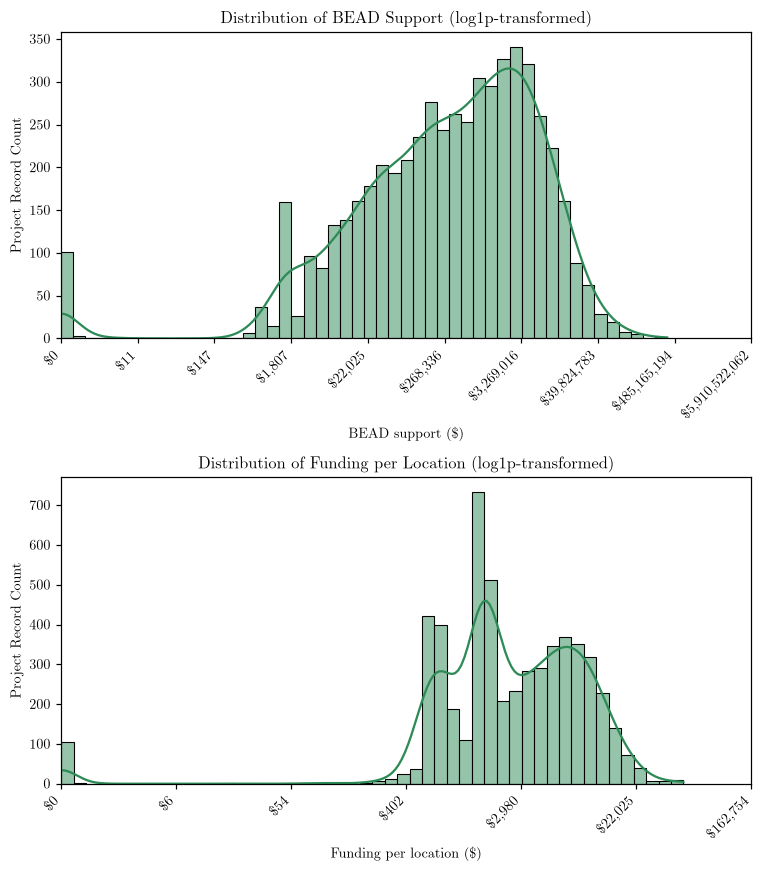

In [251]:
eda = df.copy()
if 'funding_per_location' not in eda.columns:
    eda['funding_per_location'] = eda['bead_support'] / eda['funded_locations'].replace(0, np.nan)
eda = eda.dropna(subset=['funding_per_location'])

# Create a 2x1 subplot grid
fig, axes = plt.subplots(2, 1, figsize=(7.0, 8.0))


def dollar_ticks(ax):
    """Relabel log1p x-ticks with the actual dollar amounts they represent, starting at $0."""
    ax.set_xlim(left=0)
    ticks = ax.get_xticks()
    ticks = ticks[ticks >= 0]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'\${np.expm1(t):,.0f}' for t in ticks], rotation=45, ha='right')


# First subplot (Index with axes[0] for a 1D array)
sns.histplot(np.log1p(eda['bead_support']), bins=50, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Distribution of BEAD Support (log1p-transformed)')
axes[0].set_xlabel('BEAD support (\$)')
axes[0].set_ylabel('Project Record Count')
dollar_ticks(axes[0])

# Second subplot
sns.histplot(np.log1p(eda['funding_per_location']), bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Funding per Location (log1p-transformed)')
axes[1].set_xlabel('Funding per location (\$)')
axes[1].set_ylabel('Project Record Count')
dollar_ticks(axes[1])

# plt.suptitle('Distribution of bead_support and funding_per_location', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('plots_cai/viz_1_1_eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


**Viz 2 - Cost by categorical drivers.** 

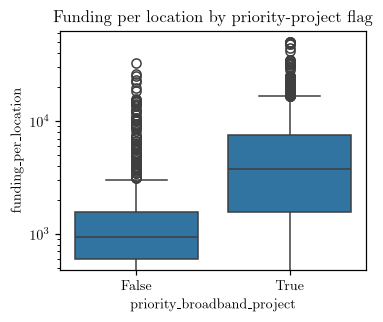

In [191]:
# Viz 2 - Target by categorical drivers (log y-axis so the skew doesn't hide the boxes)
plt.figure(figsize=(3.5, 3.0))

sns.boxplot(data=eda, x='priority_broadband_project', y='funding_per_location')
plt.yscale('log')
plt.title('Funding per location by priority-project flag')
plt.xlabel('priority_broadband_project')

plt.tight_layout()
plt.savefig('plots_cai/viz_2_eda_categorical.png', dpi=300)
plt.show()

**Viz 2b - What kinds of projects are "priority"?** 

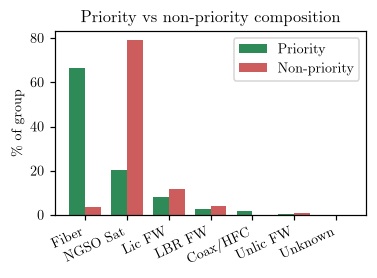

In [192]:
# Viz 2b - Technology mix of priority projects (and priority vs non-priority)
tech_labels = {0:'Unknown',10:'DSL',40:'Coax/HFC',50:'Fiber',60:'GSO Sat',
               61:'NGSO Sat',70:'Unlic FW',71:'Lic FW',72:'LBR FW'}
p = df.copy()
p['tech'] = p['dominant_technology'].map(tech_labels).fillna('Other')
p['grp'] = np.where(p['priority_broadband_project'] == True, 'Priority', 'Non-priority')

order = p[p['grp']=='Priority']['tech'].value_counts().index.tolist()
share = (p.groupby('grp')['tech'].value_counts(normalize=True)*100).unstack().reindex(columns=order).fillna(0)
pc = p[p['grp']=='Priority']['tech'].value_counts().reindex(order)



x = np.arange(len(order)); w = 0.38
plt.bar(x-w/2, share.loc['Priority', order].values, w, label='Priority', color='seagreen')
plt.bar(x+w/2, share.loc['Non-priority', order].values, w, label='Non-priority', color='indianred')
plt.xticks(x, order, rotation=25, ha='right')
plt.ylabel(r'\% of group')
plt.title('Priority vs non-priority composition')
plt.legend()

plt.tight_layout()
plt.savefig('plots_cai/viz_2b_priority_project_types.png', dpi=300, bbox_inches='tight')
plt.show()

**Viz 3 - Correlation matrix.** 

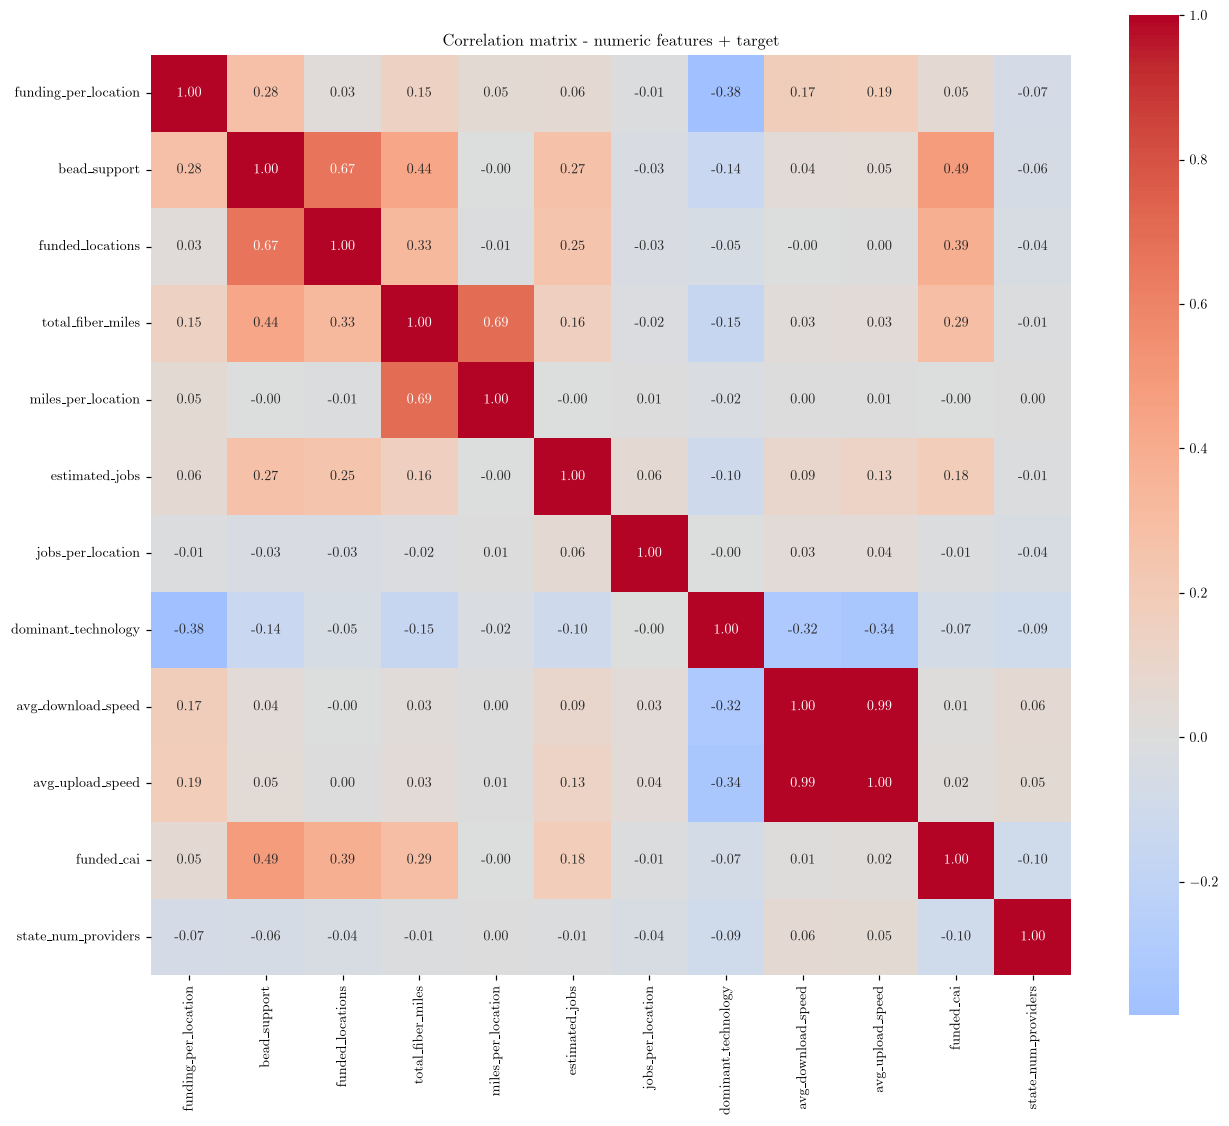

In [193]:
# Viz 3 - Correlation among numeric features and the target
eda['total_fiber_miles'] = eda['estimated_miles_aerial_fiber'].fillna(0) + eda['estimated_miles_buried_fiber'].fillna(0)
eda['miles_per_location'] = eda['total_fiber_miles'] / eda['funded_locations'].replace(0, np.nan)
eda['jobs_per_location']  = eda['estimated_jobs'] / eda['funded_locations'].replace(0, np.nan)

num_cols = ['funding_per_location', 'bead_support', 'funded_locations', 'total_fiber_miles',
            'miles_per_location', 'estimated_jobs', 'jobs_per_location',
            'dominant_technology', 'avg_download_speed', 'avg_upload_speed',
            'funded_cai', 'state_num_providers']
corr = eda[num_cols].fillna(0).corr()

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix - numeric features + target')
plt.tight_layout()
plt.savefig('plots_cai/viz_3_eda_corr.png', dpi=300)
plt.show()

**Viz 4 - Cost by state.** Three per-state metrics on `funding_per_location`: the **weighted mean** ($\sum$bead_support / $\sum$funded_locations \u2014 the metric comparable to official program totals like CPUC filings), the **simple mean of per-project ratios** (equal-weights every project regardless of size), and the **median** (robust to single-location outlier projects). States with $\\ge$ 5 projects.

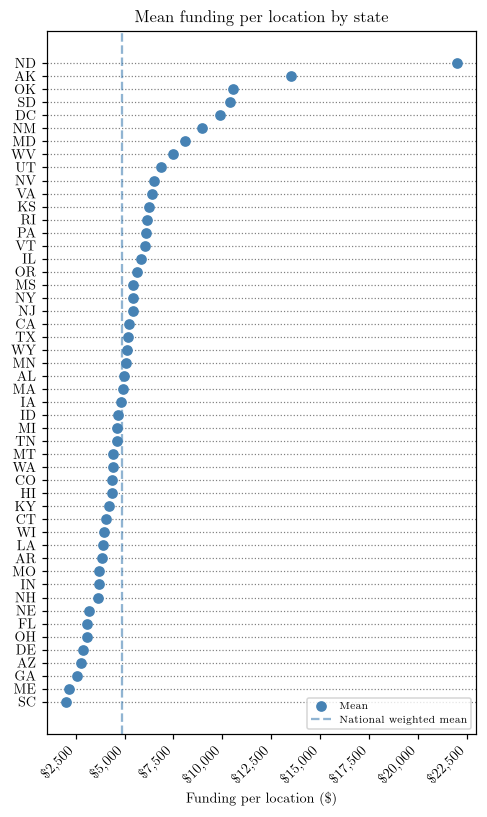

In [241]:
# Viz 4a - Funding per location by state: weighted mean vs simple mean vs median
def weighted_mean(g):
    return g['bead_support'].sum() / g['funded_locations'].sum()

state_metrics = (
    eda.groupby('state')
       .apply(lambda g: pd.Series({
           'weighted_mean': weighted_mean(g),
           'simple_mean': g['funding_per_location'].mean(),
           'median': g['funding_per_location'].median(),
           'count': len(g),
       }))
    #    .query('count >= 5')
       .sort_values('weighted_mean', ascending=False)
)

national_weighted = eda['bead_support'].sum() / eda['funded_locations'].sum()

plt.figure(figsize=(4.5, 7.5))
ax = plt.gca()
y = range(len(state_metrics))
for yi in y:
    ax.axhline(yi, color='gray', linestyle=':', linewidth=0.8, zorder=0)
plt.plot(state_metrics['weighted_mean'], y, 'o', color='steelblue', zorder=3,
         label=r'Mean')
# plt.plot(state_metrics['simple_mean'], y, 's', color='indianred', zorder=2, alpha=0.8,
#          label='Simple mean of per-project ratio')
# plt.plot(state_metrics['median'], y, '^', color='seagreen', zorder=2, alpha=0.8,
#          label='Median of per-project ratio')
plt.yticks(list(y), state_metrics.index)
plt.gca().invert_yaxis()
plt.axvline(national_weighted, color='steelblue', linestyle='--', alpha=0.6,
            label='National weighted mean')
plt.xscale('linear')
currency_formatter = plt.FuncFormatter(lambda value, _: f'\${value:,.0f}')
ax.xaxis.set_major_formatter(currency_formatter)
ax.minorticks_off()
plt.xticks(rotation=45, ha = "right")
plt.xlabel(r'Funding per location (\$)')
plt.legend(loc='lower right', fontsize=6.5)
plt.title('Mean funding per location by state')
plt.tight_layout()
plt.savefig('plots_cai/viz_4a_eda_state', dpi=300)
plt.show()


**Viz 4b - Project count by state.** Number of funded projects per state, ordered by frequency.

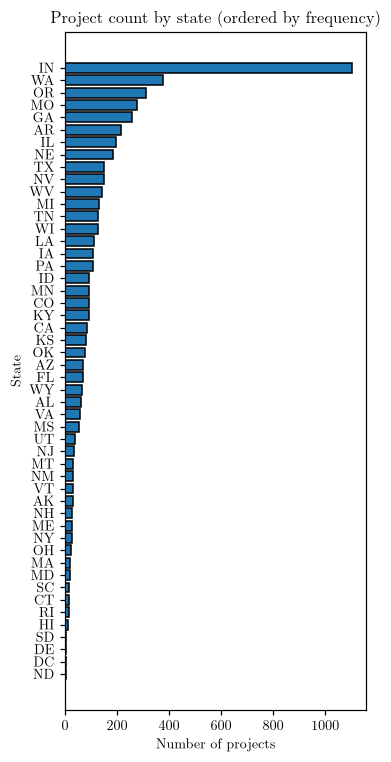

In [195]:
state_counts = eda['state'].value_counts().sort_values()

plt.figure(figsize=(3.5, 7.0))
plt.barh(state_counts.index, state_counts.values, edgecolor='black')
plt.xlabel('Number of projects')
plt.ylabel('State')
plt.title('Project count by state (ordered by frequency)')
plt.tight_layout()
plt.savefig('plots_cai/viz_4b_eda_state_count', dpi=300)
plt.show()

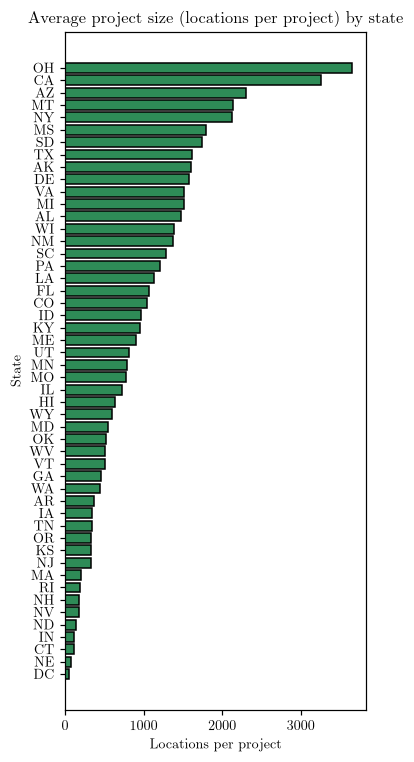

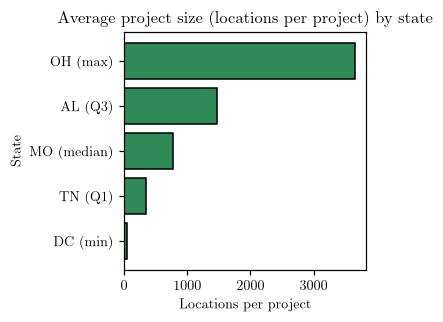

In [254]:
# Viz 4b_i - Average project size (locations per project) by state
avg_size = eda.groupby('state')['funded_locations'].mean().sort_values()

plt.figure(figsize=(3.5, 7.0))
plt.barh(avg_size.index, avg_size.values, edgecolor='black', color='seagreen')
plt.xlabel('Locations per project')
plt.ylabel('State')
plt.title('Average project size (locations per project) by state')
plt.tight_layout()
plt.savefig('plots_cai/viz_4b_i_eda_state_avg_project_size', dpi=300)
plt.show()

# Viz 4e - Viz-4b-style count bars, but only the 5 states at the distribution boundaries
# counts = eda['state'].value_counts().sort_values()   # ascending, like Viz 4b
n = len(avg_size)
pos = [int(round(pct/100*(n-1))) for pct in (0, 25, 50, 75, 100)]
tags = ['min', 'Q1', 'median', 'Q3', 'max']
sel = avg_size.iloc[pos]
labels = [f'{s} ({t})' for s, t in zip(sel.index, tags)]

plt.figure(figsize=(3.5, 3.0))
plt.barh(labels, sel.values, edgecolor='black',color='seagreen')
plt.xlabel('Locations per project')
plt.ylabel('State')
plt.title('Average project size (locations per project) by state')
plt.tight_layout()
plt.savefig('plots_cai/viz_4b_iv_eda_state_count_boundaries', dpi=300)
plt.show()

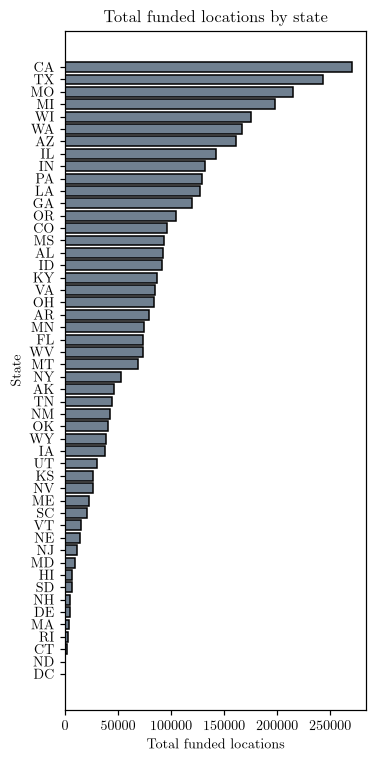

In [197]:
# Viz 4b_ii - Total funded locations by state
total_locs = eda.groupby('state')['funded_locations'].sum().sort_values()

plt.figure(figsize=(3.5, 7.0))
plt.barh(total_locs.index, total_locs.values, edgecolor='black', color='slategray')
plt.xlabel('Total funded locations')
plt.ylabel('State')
plt.title('Total funded locations by state')
plt.tight_layout()
plt.savefig('plots_cai/viz_4b_ii_eda_state_total_locations', dpi=300)
plt.show()


**Viz 4b_iii - Average project size at project-count boundaries.** Average funded locations per project for the five states at the minimum, 25th percentile, median, 75th percentile, and maximum of the per-state project-count distribution. The label reports each selected state's project count.

*Dataset: bead_cai.csv*

![Viz 4b_iii: average project size at project-count boundaries](plots_cai/viz_4b_iii_eda_state_avg_project_size_count_boundaries.png)

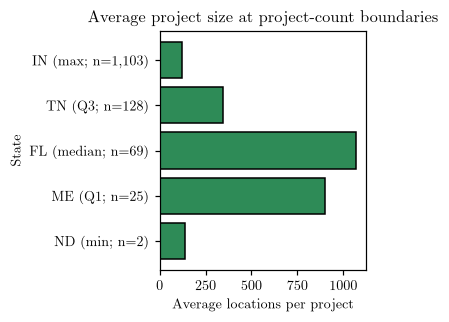

In [246]:
# Viz 4b_iii - Average project size for states at the project-count distribution boundaries
project_counts = eda['state'].value_counts().sort_values()
n = len(project_counts)
positions = [int(round(pct / 100 * (n - 1))) for pct in (0, 25, 50, 75, 100)]
tags = ['min', 'Q1', 'median', 'Q3', 'max']
selected_counts = project_counts.iloc[positions]
selected_avg_size = (eda.groupby('state')['funded_locations'].mean()
                        .reindex(selected_counts.index))
labels = [f'{state} ({tag}; n={count:,})'
          for state, tag, count in zip(selected_counts.index, tags, selected_counts.values)]

plt.figure(figsize=(3.5, 3.0))
plt.barh(labels, selected_avg_size.values, edgecolor='black', color='seagreen')
plt.xlabel('Average locations per project')
plt.ylabel('State')
plt.title('Average project size at project-count boundaries')
plt.tight_layout()
plt.savefig('plots_cai/viz_4b_iii_eda_state_avg_project_size_count_boundaries',
            dpi=300, bbox_inches='tight')
plt.show()


**Viz 4c - Cost and volume by state (merged).** Left: weighted mean `funding_per_location` per state ($\sum$support/$\sum$locations, the CPUC-comparable metric) with bootstrap 95\% CI, plus simple mean and median overlaid for comparison. Right = number of funded projects, same state order. States with $\ge$ 5 projects.

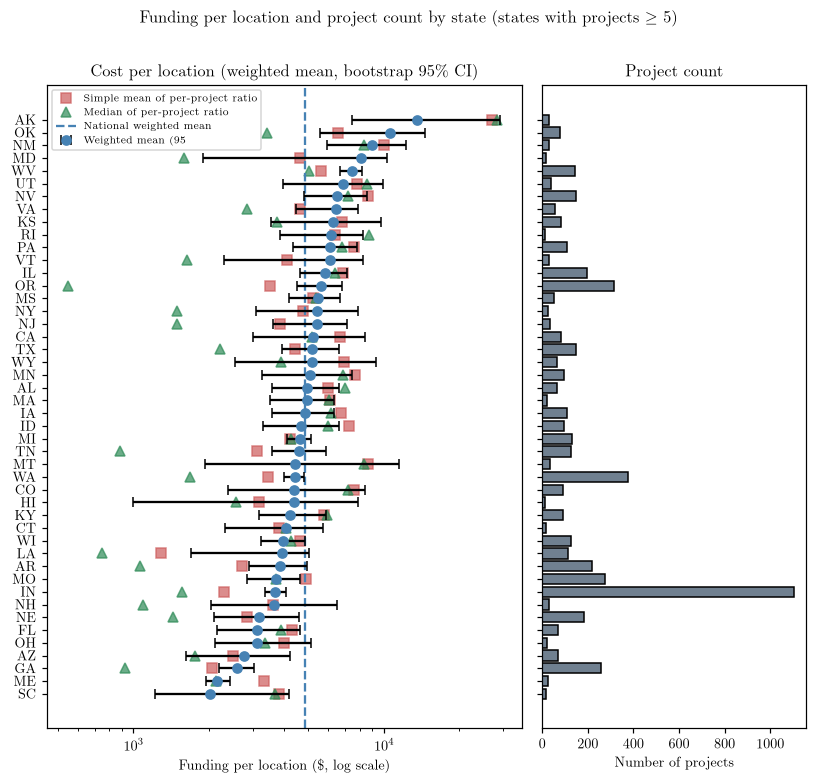

In [198]:
# Viz 4c - Merged: weighted mean funding per location (left, with simple mean + median overlay) + project count (right)
rng = np.random.default_rng(42)
B = 2000

def boot_weighted_mean_ci(g, n_boot=B, alpha=0.05):
    support = g['bead_support'].values
    locations = g['funded_locations'].values
    n = len(g)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_ratios = support[idx].sum(axis=1) / locations[idx].sum(axis=1)
    lo, hi = np.percentile(boot_ratios, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return support.sum() / locations.sum(), lo, hi

rows = []
for state, g in eda.groupby('state'):
    if len(g) >= 5:
        m, lo, hi = boot_weighted_mean_ci(g)
        rows.append((state, m, lo, hi, g['funding_per_location'].mean(),
                     g['funding_per_location'].median(), len(g)))
stats = (pd.DataFrame(rows, columns=['state', 'weighted_mean', 'lo', 'hi',
                                      'simple_mean', 'median', 'count'])
           .set_index('state').sort_values('weighted_mean', ascending=False))

national_weighted = eda['bead_support'].sum() / eda['funded_locations'].sum()

y = np.arange(len(stats))
xerr = np.vstack([stats['weighted_mean'] - stats['lo'], stats['hi'] - stats['weighted_mean']])

fig, axes = plt.subplots(1, 2, figsize=(7.5, 7.0), sharey=True,
                         gridspec_kw={'width_ratios': [1.8, 1]})

# Left: weighted mean funding per location with bootstrap 95% CI, plus simple mean / median overlay
axes[0].errorbar(stats['weighted_mean'], y, xerr=xerr, fmt='o', color='steelblue',
                 ecolor='black', capsize=3, zorder=3, label='Weighted mean (95% CI)')
axes[0].plot(stats['simple_mean'], y, 's', color='indianred', alpha=0.7, zorder=2,
             label='Simple mean of per-project ratio')
axes[0].plot(stats['median'], y, '^', color='seagreen', alpha=0.7, zorder=2,
             label='Median of per-project ratio')
axes[0].axvline(national_weighted, color='steelblue', linestyle='--',
                label='National weighted mean')
axes[0].set_xscale('log')
axes[0].set_yticks(y)
axes[0].set_yticklabels(stats.index)
axes[0].invert_yaxis()
axes[0].set_xlabel(r'Funding per location (\$, log scale)')
axes[0].set_title(r'Cost per location (weighted mean, bootstrap 95\% CI)')
axes[0].legend(fontsize=6.5)

# Right: project count, same state order
axes[1].barh(y, stats['count'].values, color='slategray', edgecolor='black')
axes[1].set_xlabel('Number of projects')
axes[1].set_title('Project count')

plt.suptitle(r'Funding per location and project count by state (states with projects $\ge$ 5)', y=1.01)
plt.tight_layout()
plt.savefig('plots_cai/viz_4c_eda_state_merged', dpi=300)
plt.show()


**Viz 4d - Cost per location at the distribution boundaries.** Same plot as Viz 4a (weighted mean `funding_per_location`, $\sum$support/$\sum$locations), but only the five states sitting at the min, 25th, median, 75th, and max of the per-state weighted means (states with $\ge$ 5 projects).

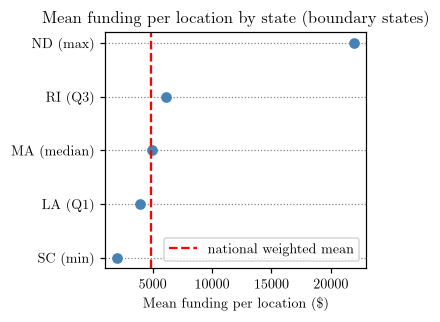

In [253]:
# Viz 4d - Viz-4a-style dot plot, but only the 5 states at the distribution boundaries (by weighted mean)
sm = (eda.groupby('state')
        .apply(lambda g: pd.Series({
            'weighted_mean': g['bead_support'].sum() / g['funded_locations'].sum(),
            'size': len(g),
        }))
        .sort_values('weighted_mean'))
n = len(sm)
pos = [int(round(pct / 100 * (n - 1))) for pct in (0, 25, 50, 75, 100)]
tags = ['min', 'Q1', 'median', 'Q3', 'max']
sel = sm.iloc[pos]

national_weighted = eda['bead_support'].sum() / eda['funded_locations'].sum()

bs = pd.DataFrame({
    'label': [f'{state} ({tag})' for state, tag in zip(sel.index, tags)],
    'weighted_mean': sel['weighted_mean'].values,
}).sort_values('weighted_mean', ascending=False)

plt.figure(figsize=(3.5, 3.0))
ax = plt.gca()
for yi in range(len(bs)):
    ax.axhline(yi, color='gray', linestyle=':', linewidth=0.8, zorder=0)
plt.plot(bs['weighted_mean'], range(len(bs)), 'o', color='steelblue', zorder=2)
plt.yticks(range(len(bs)), bs['label'])
plt.gca().invert_yaxis()
plt.axvline(national_weighted, color='red', linestyle='--', label='national weighted mean')
plt.xlabel(r'Mean funding per location (\$)')
plt.legend()
plt.title('Mean funding per location by state (boundary states)')
plt.tight_layout()
plt.savefig('plots_cai/viz_4d_eda_state_boundaries', dpi=300)
plt.show()


**Viz 4e - Project count at the distribution boundaries.** Same plot as Viz 4b (project count bars), but only the five states sitting at the min, 25th, median, 75th, and max of the per-state project counts.

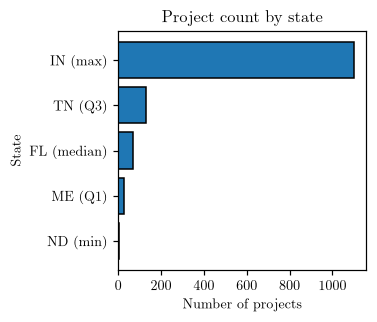

In [242]:
# Viz 4e - Viz-4b-style count bars, but only the 5 states at the distribution boundaries
counts = eda['state'].value_counts().sort_values()   # ascending, like Viz 4b
n = len(counts)
pos = [int(round(pct/100*(n-1))) for pct in (0, 25, 50, 75, 100)]
tags = ['min', 'Q1', 'median', 'Q3', 'max']
sel = counts.iloc[pos]
labels = [f'{s} ({t})' for s, t in zip(sel.index, tags)]

plt.figure(figsize=(3.5, 3.0))
plt.barh(labels, sel.values, edgecolor='black')
plt.xlabel('Number of projects')
plt.ylabel('State')
plt.title('Project count by state')
plt.tight_layout()
plt.savefig('plots_cai/viz_4e_eda_state_count_boundaries', dpi=300)
plt.show()


**Viz 4f - Cost by state (landscape).** Viz 4a with the aspect ratio flipped: states on the x-axis, weighted `funding_per_location` ($\sum$support/$\sum$locations, bootstrap 95\% CI) on the y-axis, sorted high to low (states with $\ge$ 5 projects).

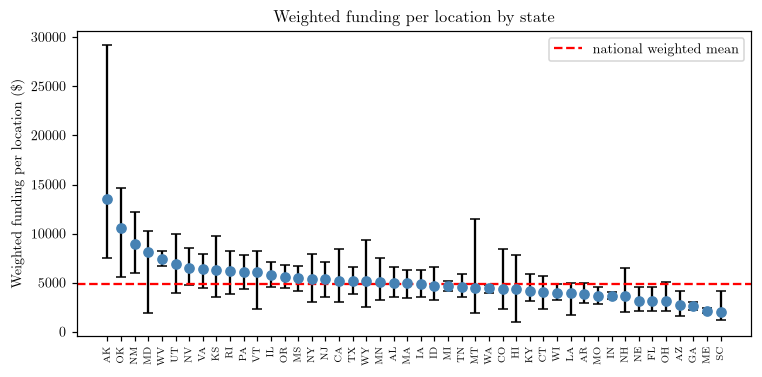

In [201]:
# Viz 4f - Viz 4a with switched aspect ratio (states on x-axis, landscape)
rng = np.random.default_rng(42)
B = 2000
def boot_weighted_mean_ci(g, n_boot=B, alpha=0.05):
    support = g['bead_support'].values
    locations = g['funded_locations'].values
    n = len(g)
    idx = rng.integers(0, n, size=(n_boot, n))
    ratios = support[idx].sum(axis=1) / locations[idx].sum(axis=1)
    lo, hi = np.percentile(ratios, [100*alpha/2, 100*(1-alpha/2)])
    return support.sum() / locations.sum(), lo, hi

rows = []
for state, g in eda.groupby('state'):
    if len(g) >= 5:
        m, lo, hi = boot_weighted_mean_ci(g)
        rows.append((state, m, lo, hi, len(g)))
state_stats = (pd.DataFrame(rows, columns=['state', 'weighted_mean', 'lo', 'hi', 'count'])
                 .set_index('state').sort_values('weighted_mean', ascending=False))

# asymmetric error bars: distance from the mean to each CI bound
yerr = np.vstack([state_stats['weighted_mean'] - state_stats['lo'],
                  state_stats['hi'] - state_stats['weighted_mean']])

plt.figure(figsize=(7.0, 3.5))
plt.errorbar(range(len(state_stats)), state_stats['weighted_mean'], yerr=yerr,
             fmt='o', color='steelblue', ecolor='black', capsize=3)
plt.xticks(range(len(state_stats)), state_stats.index, rotation=90, fontsize=6)
national_weighted = eda['bead_support'].sum() / eda['funded_locations'].sum()
plt.axhline(national_weighted, color='red', linestyle='--', label='national weighted mean')
plt.ylabel(r'Weighted funding per location (\$)')
plt.legend()
plt.title(r'Weighted funding per location by state')
plt.tight_layout()
plt.savefig('plots_cai/viz_4f_eda_state_landscape', dpi=300)
plt.show()


**Viz 4g - Project count by state (landscape).** Viz 4b with the aspect ratio flipped: states on the x-axis, number of funded projects on the y-axis, ordered by frequency.

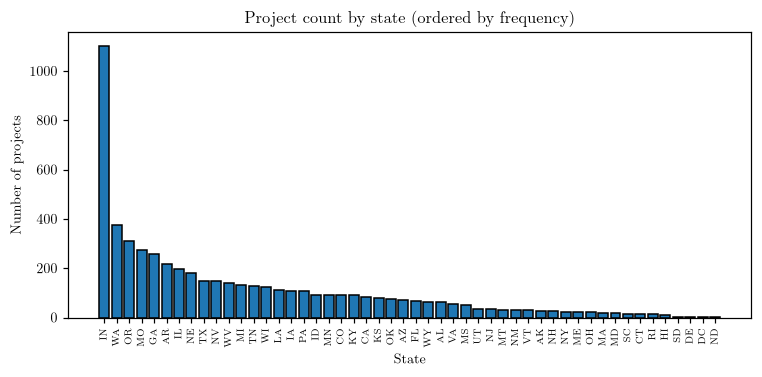

In [202]:
# Viz 4g - Viz 4b with switched aspect ratio (states on x-axis, landscape)
state_counts = eda['state'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(7.0, 3.5))
plt.bar(range(len(state_counts)), state_counts.values, edgecolor='black')
plt.xticks(range(len(state_counts)), state_counts.index, rotation=90, fontsize=6)
plt.ylabel('Number of projects')
plt.xlabel('State')
plt.title('Project count by state (ordered by frequency)')
plt.tight_layout()
plt.savefig('plots_cai/viz_4g_eda_state_count_landscape', dpi=300)
plt.show()


**Viz 4h - Viz-4a-style dot plot, faceted by dominant technology type.** Every state/technology point and reference line uses $\sum$support/$\sum$locations.

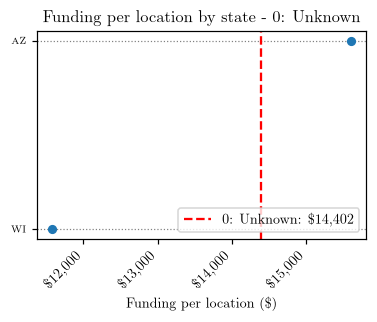

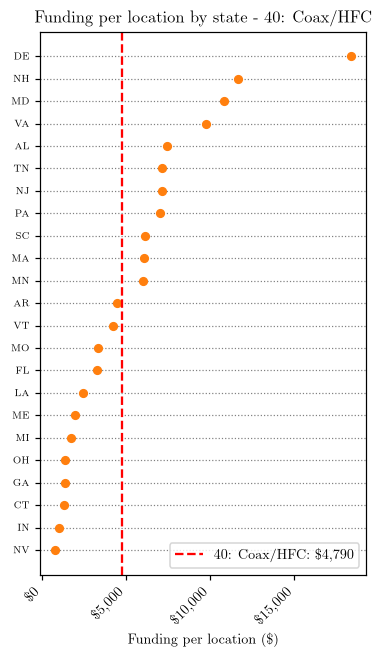

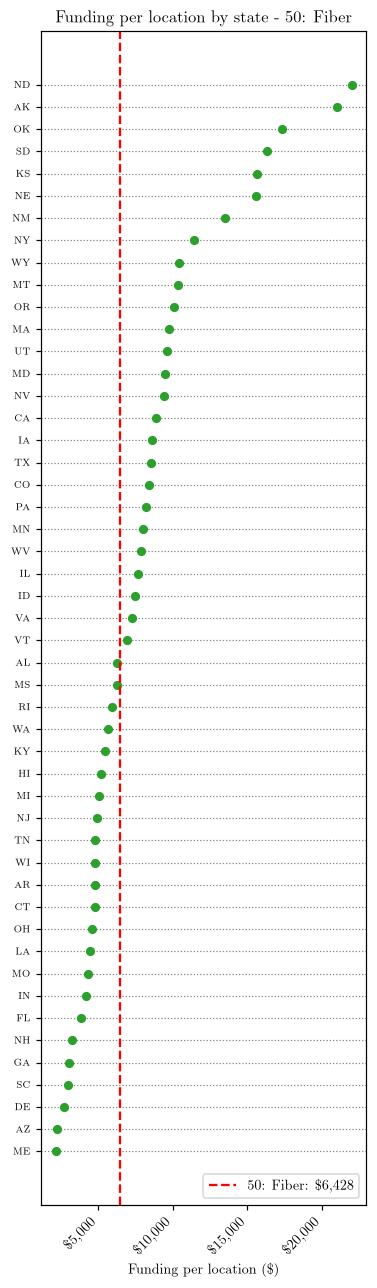

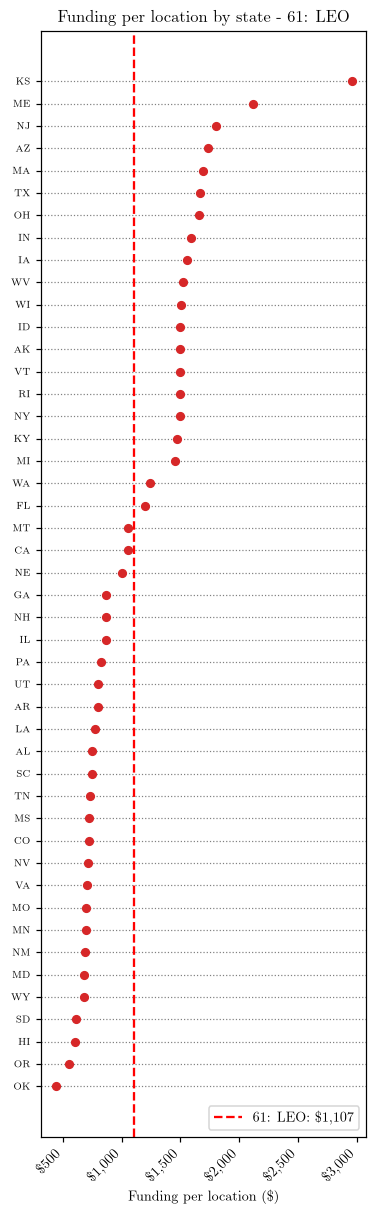

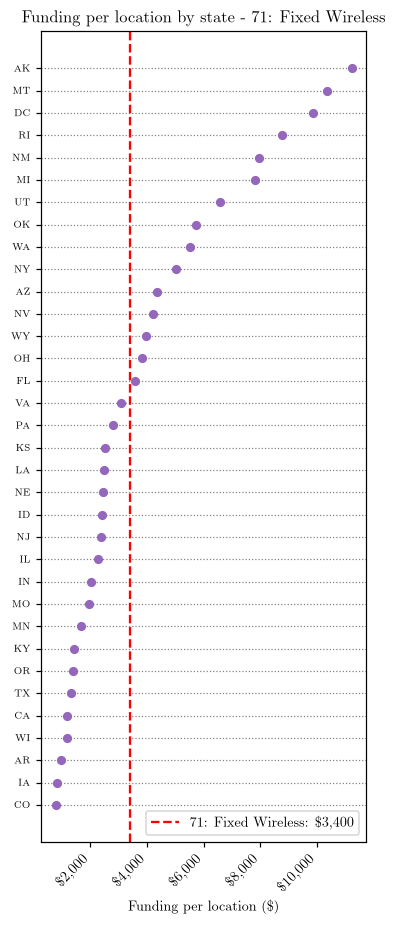

In [279]:
# Viz 4h - Viz-4a-style dot plot, one separate figure per dominant technology type

tech_labels = {0:'0: Unknown',10:'10: DSL',40:'40: Coax/HFC',50:'50: Fiber',60:'61: LEO',
               61:'61: LEO',70:'71: Fixed Wireless',71:'71: Fixed Wireless',72:'71: Fixed Wireless'}



th = eda.copy()
th['tech_name'] = th['dominant_technology'].map(tech_labels).fillna('Other')

state_order = (eda.groupby('state')
                 .apply(lambda g: g['bead_support'].sum() / g['funded_locations'].sum())
                 .sort_values(ascending=False).index.tolist())

grp = (th.groupby(['state', 'tech_name'])
         .agg(total_support=('bead_support', 'sum'),
              total_locations=('funded_locations', 'sum'),
              count=('project_id', 'size'))
         .query('count >= 1 and total_locations > 0')
         .reset_index())
grp['weighted_funding_per_location'] = grp['total_support'] / grp['total_locations']
grp['state'] = pd.Categorical(grp['state'], categories=state_order, ordered=True)
grp = grp.sort_values('state')

techs = sorted(grp['tech_name'].unique())
palette = dict(zip(techs, sns.color_palette('tab10', n_colors=len(techs))))
national_weighted = eda['bead_support'].sum() / eda['funded_locations'].sum()


def to_roman(n):
    vals = [(10, 'x'), (9, 'ix'), (5, 'v'), (4, 'iv'), (1, 'i')]
    out = ''
    for v, sym in vals:
        while n >= v:
            out += sym
            n -= v
    return out


def dollar_xticks(ax):
    """Format x-ticks as dollar amounts, rotate 45deg."""
    xlim = ax.get_xlim()
    ticks = [t for t in ax.get_xticks() if xlim[0] <= t <= xlim[1]]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'\${v:,.0f}' for v in ticks], rotation=45, ha='right')


for idx, t in enumerate(techs, start=1):
    sub = (grp[grp['tech_name'] == t]
             .sort_values('weighted_funding_per_location', ascending=False)
             .reset_index(drop=True))
    states = sub['state'].tolist()
    y = range(len(states))
    tech_rows = th[th['tech_name'] == t]
    tech_weighted = tech_rows['bead_support'].sum() / tech_rows['funded_locations'].sum()

    height = max(3.0, 0.22 * len(states) + 1.0)
    plt.figure(figsize=(3.5, height))
    ax = plt.gca()
    for yi in y:
        ax.axhline(yi, color='gray', linestyle=':', linewidth=0.8, zorder=0)
    plt.plot(sub['weighted_funding_per_location'], y, 'o', color=palette[t], markersize=5, zorder=2)
    plt.yticks(list(y), states, fontsize=6)
    plt.gca().invert_yaxis()
    plt.axvline(tech_weighted, color='red', linestyle='--',
                label=f'{t}: \${tech_weighted:,.0f}')
    plt.xlabel(r'Funding per location (\$)')
    dollar_xticks(ax)
    plt.legend(loc='lower right')
    plt.title(f'Funding per location by state - {t}')
    plt.tight_layout()
    tag = to_roman(idx)
    plt.savefig(f'plots_cai/viz_4h_{tag}_eda_state_{t.lower().replace(" ", "_").replace("/", "_")}',
                dpi=300, bbox_inches='tight')
    plt.show()


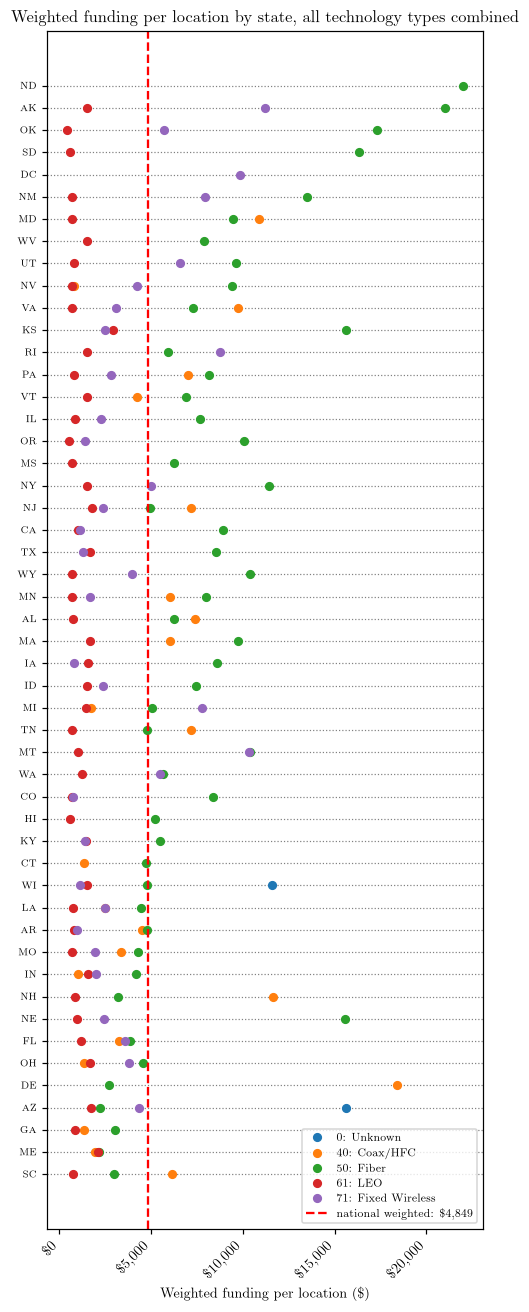

In [260]:
# Viz 4i - All technology types combined onto one dot plot (like 4h, merged)
present_states = [s for s in state_order if s in set(grp['state'])]
y_map = {s: i for i, s in enumerate(present_states)}

height = max(1.5, 0.22 * len(present_states) + 1.0)
plt.figure(figsize=(4.5, height))
ax = plt.gca()
for yi in range(len(present_states)):
    ax.axhline(yi, color='gray', linestyle=':', linewidth=0.8, zorder=0)

for t in techs:
    sub = grp[(grp['tech_name'] == t) & (grp['state'].isin(present_states))]
    y = [y_map[s] for s in sub['state']]
    plt.plot(sub['weighted_funding_per_location'], y, 'o', color=palette[t], label=t, markersize=5, zorder=2)

plt.yticks(range(len(present_states)), present_states, fontsize=6)
plt.gca().invert_yaxis()
plt.axvline(national_weighted, color='red', linestyle='--',
            label=f'national weighted: \${national_weighted:,.0f}')
plt.xlabel(r'Weighted funding per location (\$)')
dollar_xticks(ax)
plt.legend(loc='lower right', fontsize=7)
plt.title('Weighted funding per location by state, all technology types combined')
plt.tight_layout()
plt.savefig('plots_cai/viz_4i_eda_state_all_technologies', dpi=300, bbox_inches='tight')
plt.show()


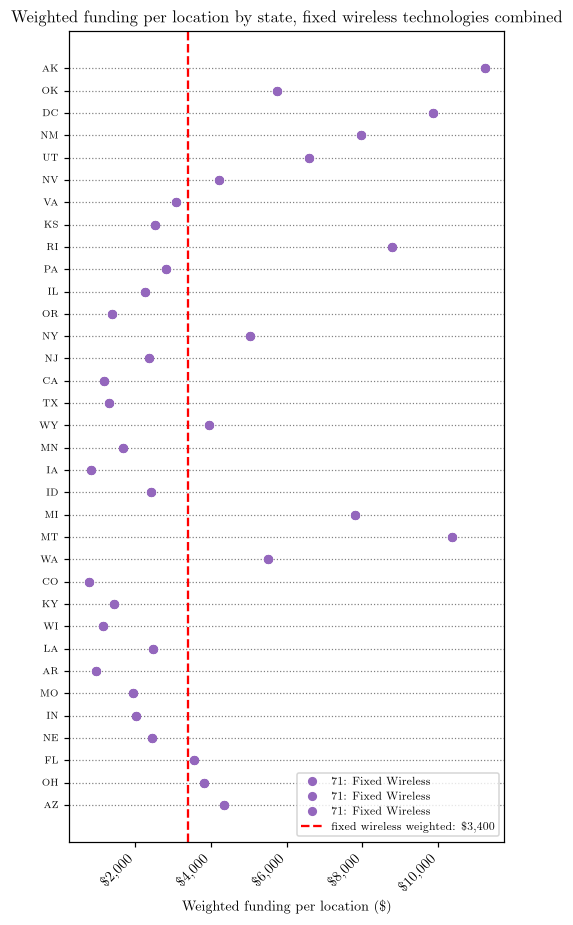

In [205]:
# Viz 4i_2 - Fixed wireless technologies combined (codes 70, 71, 72)
fw_codes = [70, 71, 72]
fw_techs = [tech_labels[c] for c in fw_codes]

fw_states = [s for s in state_order if s in set(grp.loc[grp['tech_name'].isin(fw_techs), 'state'])]
fw_y_map = {s: i for i, s in enumerate(fw_states)}
fw_rows = th[th['dominant_technology'].isin(fw_codes)]
fw_weighted = fw_rows['bead_support'].sum() / fw_rows['funded_locations'].sum()

height = max(3.0, 0.22 * len(fw_states) + 1.0)
plt.figure(figsize=(4.5, height))
ax = plt.gca()
for yi in range(len(fw_states)):
    ax.axhline(yi, color='gray', linestyle=':', linewidth=0.8, zorder=0)

for t in fw_techs:
    sub = grp[(grp['tech_name'] == t) & (grp['state'].isin(fw_states))]
    y = [fw_y_map[s] for s in sub['state']]
    plt.plot(sub['weighted_funding_per_location'], y, 'o', color=palette[t], label=t, markersize=5, zorder=2)

plt.yticks(range(len(fw_states)), fw_states, fontsize=6)
plt.gca().invert_yaxis()
plt.axvline(fw_weighted, color='red', linestyle='--',
            label=f'fixed wireless weighted: \${fw_weighted:,.0f}')
plt.xlabel(r'Weighted funding per location (\$)')
dollar_xticks(ax)
plt.legend(loc='lower right', fontsize=7)
plt.title('Weighted funding per location by state, fixed wireless technologies combined')
plt.tight_layout()
plt.savefig('plots_cai/viz_4i_2_eda_state_fixed_wireless', dpi=300, bbox_inches='tight')
plt.show()


**Viz 5 - feature vs. target.** Log-scaled scatters of `funding_per_location` against its two strongest physical drivers.

- **Funded locations (log-log):** cost per location *rises* slightly with size - no economies of scale.
- **Fiber miles per location:** strongly positive and monotone. Linear corr looks tiny only because the trend is nonlinear. x clipped at the 99th pct.

Build intensity and scale carry real, nonlinear signal (ideal for a random forest).

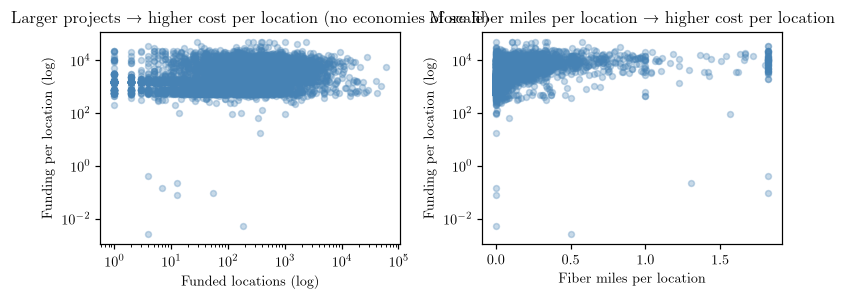

In [206]:
# Viz 5 - Key feature vs target relationships
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))

axes[0].scatter(eda['funded_locations'], eda['funding_per_location'],
                alpha=0.3, s=15, color='steelblue')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Funded locations (log)')
axes[0].set_ylabel('Funding per location (log)')
axes[0].set_title('Larger projects → higher cost per location (no economies of scale)')

mpl = eda['miles_per_location'].clip(upper=eda['miles_per_location'].quantile(0.99))
axes[1].scatter(mpl, eda['funding_per_location'], alpha=0.3, s=15, color='steelblue')
axes[1].set_yscale('log')
axes[1].set_xlabel('Fiber miles per location')
axes[1].set_ylabel('Funding per location (log)')
axes[1].set_title('More fiber miles per location → higher cost per location')

plt.tight_layout()
plt.savefig('plots_cai/viz_5_eda_scatter.png', dpi=300)
plt.show()

**Viz 6 - BEAD support vs fiber miles.** Log-log scatter of total funding against total fiber miles, colored by aerial vs buried-dominant. The aerial/buried split shows little separation.

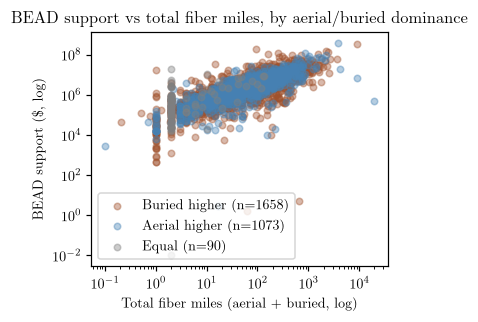

In [207]:
# Viz 6 - BEAD support vs total fiber miles, colored by aerial vs buried dominance
sc = df.copy()
sc['total_fiber_miles'] = sc['estimated_miles_aerial_fiber'].fillna(0) + sc['estimated_miles_buried_fiber'].fillna(0)
sc = sc[(sc['total_fiber_miles'] > 0) & (sc['bead_support'] > 0)]

aerial = sc['estimated_miles_aerial_fiber'].fillna(0)
buried = sc['estimated_miles_buried_fiber'].fillna(0)
sc['fiber_mix'] = np.where(buried > aerial, 'Buried higher',
                  np.where(aerial > buried, 'Aerial higher', 'Equal'))

colors = {'Buried higher': 'sienna', 'Aerial higher': 'steelblue', 'Equal': 'gray'}

plt.figure(figsize=(3.5, 3.0))
for label, color in colors.items():
    grp = sc[sc['fiber_mix'] == label]
    plt.scatter(grp['total_fiber_miles'], grp['bead_support'],
                alpha=0.4, s=18, color=color, label=f'{label} (n={len(grp)})')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('Total fiber miles (aerial + buried, log)')
plt.ylabel('BEAD support (\$, log)')
plt.title('BEAD support vs total fiber miles, by aerial/buried dominance')
plt.legend()
plt.tight_layout()
plt.savefig('plots_cai/viz_6_eda_fiber_mix_scatter.png', dpi=300)
plt.show()


In [208]:
df['dominant_technology'].value_counts()
# sometimes locations have state and federal funds to make them broadband accessible

dominant_technology
50.0    2805
61.0    1887
71.0     494
72.0     158
40.0      79
70.0      34
0.0        3
60.0       2
Name: count, dtype: int64

**Viz 7 - Cost by technology.** Box plots of BEAD support per project by dominant technology (log y), ordered by median. Wireline (fiber/coax) sits well above wireless/satellite.

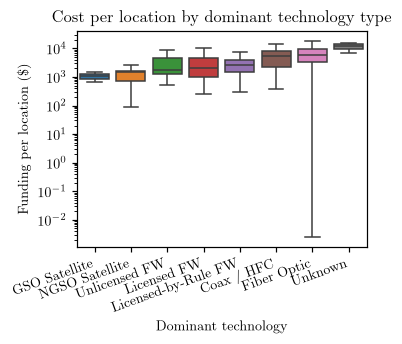

In [209]:
# Viz 7 - Cost (funding per location) by dominant technology type, color-coded by technology
tech = df.copy()
tech['funding_per_location'] = tech['bead_support'] / tech['funded_locations'].replace(0, np.nan)
tech = tech.dropna(subset=['funding_per_location'])
tech = tech[tech['funding_per_location'] > 0]

# FCC BDC technology codes -> human-readable labels
tech_labels = {
    0:  'Unknown',
    10: 'Digital Subscriber Line ',
    40: 'Coax / HFC',
    50: 'Fiber Optic',
    60: 'GSO Satellite',
    61: 'NGSO Satellite',
    70: 'Unlicensed FW',
    71: 'Licensed FW',
    72: 'Licensed-by-Rule FW',
}
tech['tech_name'] = tech['dominant_technology'].map(tech_labels).fillna('Other')

# Order categories by median cost per location so the plot reads left-to-right
order = (tech.groupby('tech_name')['funding_per_location'].median()
             .sort_values().index.tolist())
palette = dict(zip(order, sns.color_palette('tab10', len(order))))

plt.figure(figsize=(3.5, 3.2))
sns.boxplot(data=tech, x='tech_name', y='funding_per_location',
            order=order, palette=palette, showfliers=False)
counts = tech['tech_name'].value_counts()
plt.xticks(range(len(order)), rotation=20, ha='right')
plt.yscale('log')
plt.xlabel('Dominant technology')
plt.ylabel('Funding per location (\$)')
plt.title('Cost per location by dominant technology type')
plt.tight_layout()
plt.savefig('plots_cai/viz_7_eda_cost_by_technology.png', dpi=300)
plt.show()


**Viz 7b - Fiber vs others.** Box plots of BEAD support per project, grouping fiber optic against all other technologies combined (log y). Fiber sits far above everything else.

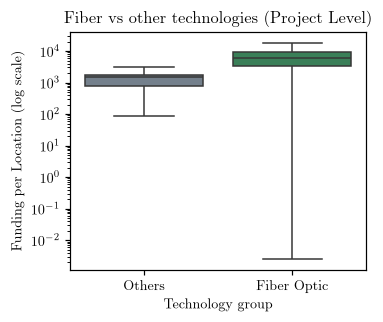

In [210]:
# Viz 7b - Fiber vs all other technologies (BEAD support per project)
techb = df.copy()
techb['funding_per_location'] = techb['bead_support'] / techb['funded_locations'].replace(0, np.nan)
techb = techb.dropna(subset=['funding_per_location'])
techb = techb[techb['funding_per_location'] > 0]

techb['fiber_group'] = np.where(techb['dominant_technology'] == 50, 'Fiber Optic', 'Others')

order = ['Others', 'Fiber Optic']
palette = {'Fiber Optic': 'seagreen', 'Others': 'slategray'}

plt.figure(figsize=(3.5, 3.0))
sns.boxplot(data=techb, x='fiber_group', y='funding_per_location',
            order=order, palette=palette, showfliers=False)
# counts = techb['fiber_group'].value_counts()
plt.xticks(range(len(order)))
plt.yscale('log')
plt.xlabel('Technology group')
plt.ylabel('Funding per Location (log scale)')
plt.title('Fiber vs other technologies (Project Level)')
plt.tight_layout()
plt.savefig('plots_cai/viz_7b_fiber_vs_others.png', dpi=300)
plt.show()

In [211]:

# df.query("dominant_technology == 0")
df.loc[df['dominant_technology'] == 0, ['project_id', 'bead_support','funded_locations']]

,project_id,bead_support,funded_locations
2661,CM61-BEAD-WI-51M001,2021200.0,163
2746,CM61-BEAD-WI-25M001,201347.0,29
4058,CM61-BEAD-AZ-44-530,6994619.0,448


**Viz 8 - QQ plots (normality check).** Raw vs `log1p` of `bead_support` and `funding_per_location` against a normal reference line. Raw values bow off the line (heavy right tail); the logged versions track it closely, justifying the log target.

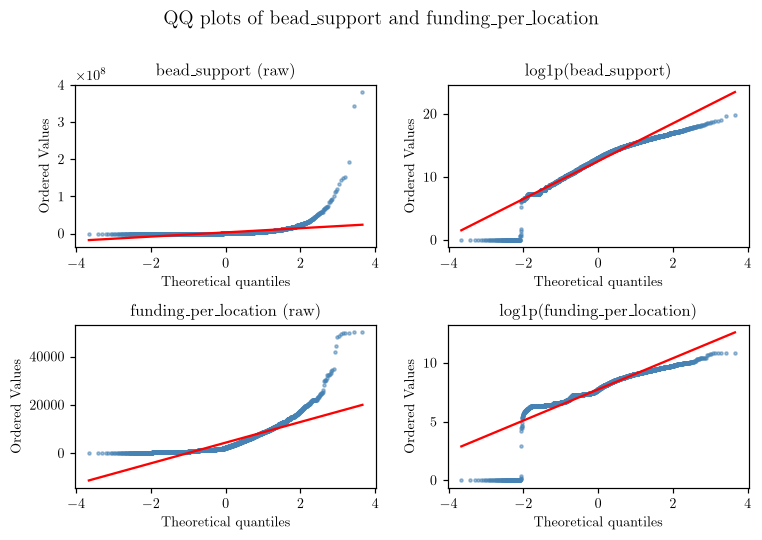

In [212]:
fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.8))

st.probplot(eda['bead_support'], dist='norm', plot=axes[0, 0])
axes[0, 0].set_title(f"bead_support (raw)")

st.probplot(np.log1p(eda['bead_support']), dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('log1p(bead_support)')

st.probplot(eda['funding_per_location'], dist='norm', plot=axes[1, 0])
axes[1, 0].set_title(f"funding_per_location (raw)")

st.probplot(np.log1p(eda['funding_per_location']), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('log1p(funding_per_location)')

# Recolor the scatter (probplot defaults to blue dots + red fit line)
for ax in axes.ravel():
    ax.get_lines()[0].set(marker='.', markersize=4, color='steelblue', alpha=0.5)
    ax.get_lines()[1].set(color='red', linewidth=1.5)

plt.suptitle('QQ plots of bead\_support and funding\_per\_location', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('plots_cai/viz_8_eda_qqplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Allocation vs Bids Scatterplot

In [213]:
deployed_projects_query = """
SELECT
    project_id,
    project_name,
    bead_support as deployed_project_bead_support,
FROM `broadband-data.fp_approved.deployment_projects`
"""

project_query = """
SELECT
    project_id,
    project_name,
    bead_support as final_proposal_bead_support,
FROM `broadband-data.final_proposal.project_clean`
"""

df_project = client.query(project_query).to_dataframe()
df_deployed = client.query(deployed_projects_query).to_dataframe()
alloted_df = df_project.merge(df_deployed, on='project_id', how='left')

**Deployed vs proposed funding.** For projects accepted into the final proposal, deployed funding vs the proposed amount (log-log, with the y = x line). Almost all points sit on the line - once accepted, the amount rarely changes.

Accepted pairs: 4469  |  amount unchanged from proposal: 86.8%


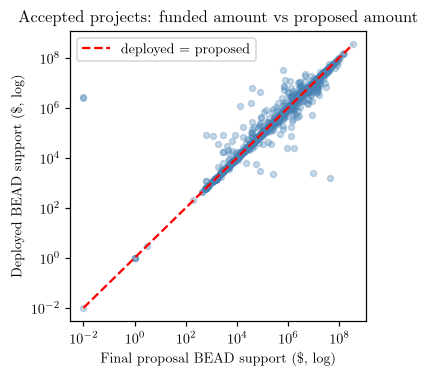

In [214]:
# Among ACCEPTED (deployed) projects: does the funded amount differ from the proposal?
# Viz 9
pair = alloted_df.dropna(subset=['deployed_project_bead_support']).copy()
pair = pair[(pair['final_proposal_bead_support'] > 0) &
            (pair['deployed_project_bead_support'] > 0)]
unchanged = (pair['final_proposal_bead_support'] == pair['deployed_project_bead_support']).mean()
print(f"Accepted pairs: {len(pair)}  |  amount unchanged from proposal: {unchanged:.1%}")

x = pair['final_proposal_bead_support']
y = pair['deployed_project_bead_support']

plt.figure(figsize=(3.5, 3.5))
plt.scatter(x, y, alpha=0.3, s=15, color='steelblue')
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims, lims, 'r--', label='deployed = proposed')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'Final proposal BEAD support (\$, log)')
plt.ylabel(r'Deployed BEAD support (\$, log)')
plt.title('Accepted projects: funded amount vs proposed amount')
plt.legend()
plt.tight_layout()
plt.savefig('plots_cai/viz_9_funded_vs_proposed.png', dpi=300, bbox_inches='tight')
plt.show()

**Viz 9b - Funded vs proposed, central 95%.** Same as Viz 9 but clipped to the central 95% of BEAD support (drop the extreme 2.5% tails on both axes), keeping the log-log scale for consistency with Viz 9.

Central 95% clip: 4290 of 4469 pairs kept (96.0%)


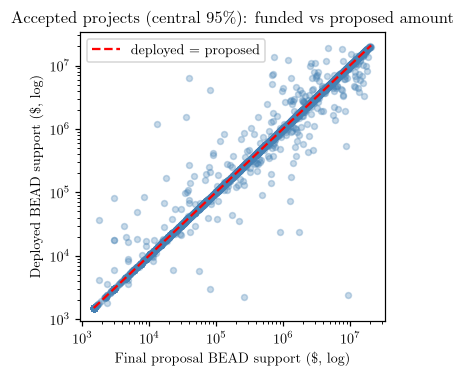

In [215]:
# Viz 9b - Viz 9 clipped to the central 95% of BEAD support (log scale, consistent with Viz 9)
# Drop the extreme 2.5% tails on BOTH axes so the bulk of accepted projects is visible.
xlo, xhi = pair['final_proposal_bead_support'].quantile([0.025, 0.975])
ylo, yhi = pair['deployed_project_bead_support'].quantile([0.025, 0.975])
clip = pair[pair['final_proposal_bead_support'].between(xlo, xhi) &
            pair['deployed_project_bead_support'].between(ylo, yhi)]
print(f"Central 95% clip: {len(clip)} of {len(pair)} pairs kept ({len(clip)/len(pair):.1%})")

x = clip['final_proposal_bead_support']
y = clip['deployed_project_bead_support']

plt.figure(figsize=(3.5, 3.5))
plt.scatter(x, y, alpha=0.3, s=15, color='steelblue')
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims, lims, 'r--', label='deployed = proposed')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'Final proposal BEAD support (\$, log)')
plt.ylabel(r'Deployed BEAD support (\$, log)')
plt.title('Accepted projects (central 95\%): funded vs proposed amount')
plt.legend()
plt.tight_layout()
plt.savefig('plots_cai/viz_9b_funded_vs_proposed_clipped.png', dpi=300, bbox_inches='tight')
plt.show()

**What predicts acceptance?** Since the amount barely changes once accepted, the real question is *which* proposals get accepted. Left: proposal-size distribution for accepted vs not; right: the same as box plots. Accepted proposals are markedly larger.

Accepted: 4469  (median proposal $485,072)
Not accepted: 1938  (median proposal $45,800)


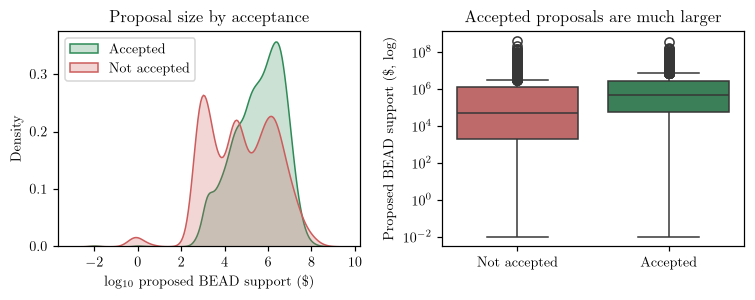

In [216]:
# The real question: does proposal SIZE predict acceptance (deployment)?
# "Accepted" = has a deployed_project_bead_support (passed final-proposal review).
sel = alloted_df[alloted_df['final_proposal_bead_support'] > 0].copy()
sel['accepted'] = sel['deployed_project_bead_support'].notna()
sel['status'] = sel['accepted'].map({True: 'Accepted', False: 'Not accepted'})
sel['log_proposal'] = np.log10(sel['final_proposal_bead_support'])

acc = sel[sel['accepted']]
rej = sel[~sel['accepted']]
print(f"Accepted: {len(acc)}  (median proposal ${acc['final_proposal_bead_support'].median():,.0f})")
print(f"Not accepted: {len(rej)}  (median proposal ${rej['final_proposal_bead_support'].median():,.0f})")

pal = {'Accepted': 'seagreen', 'Not accepted': 'indianred'}

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))
sns.kdeplot(data=acc, x='log_proposal', fill=True, color='seagreen', label='Accepted', ax=axes[0])
sns.kdeplot(data=rej, x='log_proposal', fill=True, color='indianred', label='Not accepted', ax=axes[0])
axes[0].set_xlabel(r'log$_{10}$ proposed BEAD support (\$)')
axes[0].set_title('Proposal size by acceptance')
axes[0].legend()

sns.boxplot(data=sel, x='status', y='final_proposal_bead_support',
            hue='status', order=['Not accepted', 'Accepted'],
            palette=pal, legend=False, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('')
axes[1].set_ylabel(r'Proposed BEAD support (\$, log)')
axes[1].set_title('Accepted proposals are much larger')
plt.tight_layout()
plt.show()

In [217]:
cov_table = "broadband-data.fcc_bdc.provider_coverage_state_level"

brand_cov = client.query(f"""
    SELECT brand_name, SUM(served_locations) AS served
    FROM `{cov_table}` GROUP BY brand_name ORDER BY served DESC LIMIT 15
""").to_dataframe()
state_prov = client.query(f"""
    SELECT state, COUNT(DISTINCT provider_id) AS providers
    FROM `{cov_table}` GROUP BY state ORDER BY providers DESC LIMIT 15
""").to_dataframe()
tech_cov = client.query(f"""
    SELECT tb.technology AS technology, SUM(tb.tech_locations) AS locations
    FROM `{cov_table}`, UNNEST(tech_breakdown) AS tb
    GROUP BY technology ORDER BY locations DESC
""").to_dataframe()


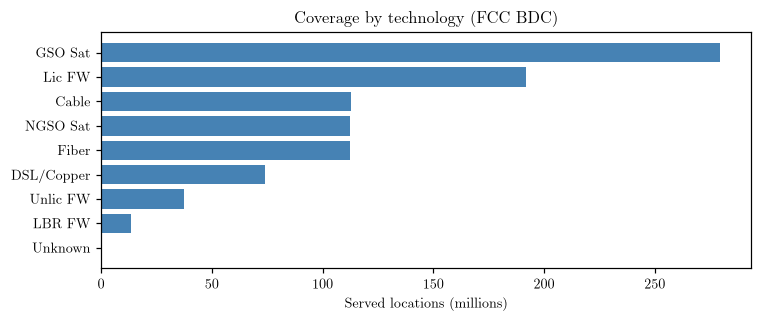

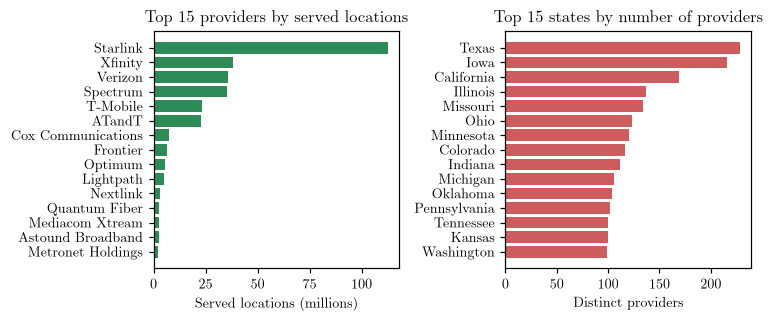

In [ ]:

cov_table = "broadband-data.fcc_bdc.provider_coverage_state_level"

brand_cov = client.query(f"""
    SELECT brand_name, SUM(served_locations) AS served
    FROM `{cov_table}` GROUP BY brand_name ORDER BY served DESC LIMIT 15
""").to_dataframe()
state_prov = client.query(f"""
    SELECT state, COUNT(DISTINCT provider_id) AS providers
    FROM `{cov_table}` GROUP BY state ORDER BY providers DESC LIMIT 15
""").to_dataframe()
tech_cov = client.query(f"""
    SELECT tb.technology AS technology, SUM(tb.tech_locations) AS locations
    FROM `{cov_table}`, UNNEST(tech_breakdown) AS tb
    GROUP BY technology ORDER BY locations DESC
""").to_dataframe()

# usetex is on for this notebook, so strip characters LaTeX chokes on (& and _)
def safe(s):
    return str(s).replace('&', 'and').replace('_', ' ')

tech_labels = {0:'Unknown', 10:'DSL/Copper', 40:'Cable', 50:'Fiber', 60:'GSO Sat',
               61:'NGSO Sat', 70:'Unlic FW', 71:'Lic FW', 72:'LBR FW'}
tech_cov['label'] = tech_cov['technology'].map(tech_labels).fillna('Other')
tech_cov = tech_cov.sort_values('locations')

# Graph 1: served locations by technology (in millions)
plt.figure(figsize=(7.0, 3.0))
plt.barh(tech_cov['label'], tech_cov['locations'] / 1e6, color='steelblue')
plt.xlabel('Served locations (millions)')
plt.title('Coverage by technology (FCC BDC)')
plt.tight_layout()i
# plt.savefig('cov_by_technology.png', dpi=300)
plt.show()

# Graph 2 & 3: top providers by served locations, and providers per state
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0))
b = brand_cov.sort_values('served')
axes[0].barh([safe(x) for x in b['brand_name']], b['served'] / 1e6, color='seagreen')
axes[0].set_xlabel('Served locations (millions)')
axes[0].set_title('Top 15 providers by served locations')

s = state_prov.sort_values('providers')
axes[1].barh([safe(x) for x in s['state']], s['providers'], color='indianred')
axes[1].set_xlabel('Distinct providers')
axes[1].set_title('Top 15 states by number of providers')

plt.tight_layout()
# plt.savefig('cov_reach_by_brand_state.png', dpi=300)
plt.show()


**Viz 10 - Distribution of funding per location, raw vs. log.** Side-by-side histograms of `funding_per_location` (raw) and `log1p(funding_per_location)` to justify the log transform. Pairs with the Viz 8 QQ plots for the normality argument.

*Dataset: bead.csv*

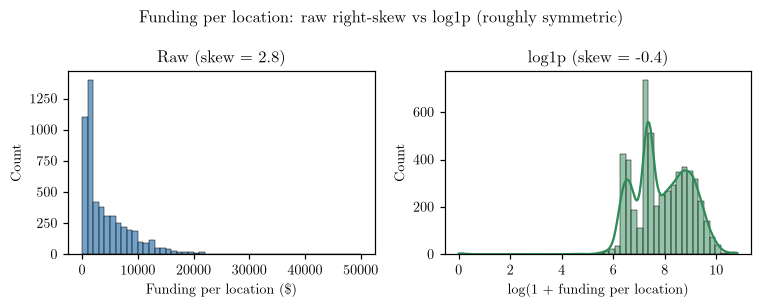

In [219]:
# Viz 10 - Distribution of funding per location: raw vs log1p
# Dataset: bead.csv
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d = d.dropna(subset=['funding_per_location'])
d = d[d['funding_per_location'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))
sns.histplot(d['funding_per_location'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title(f"Raw (skew = {d['funding_per_location'].skew():.1f})")
axes[0].set_xlabel(r'Funding per location (\$)')

logv = np.log1p(d['funding_per_location'])
sns.histplot(logv, bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"log1p (skew = {logv.skew():.1f})")
axes[1].set_xlabel(r'log(1 + funding per location)')

plt.suptitle('Funding per location: raw right-skew vs log1p (roughly symmetric)')
plt.tight_layout()
# plt.savefig('plots_cai/viz_10_dist_funding_raw_vs_log.png', dpi=300, bbox_inches='tight')
plt.show()

**Viz 11 - Choropleth of weighted funding per location by state.** US state map colored by $\sum$bead_support / $\sum$funded_locations for each state.

*Dataset: bead.csv (state-level aggregate; 2-letter state codes)*

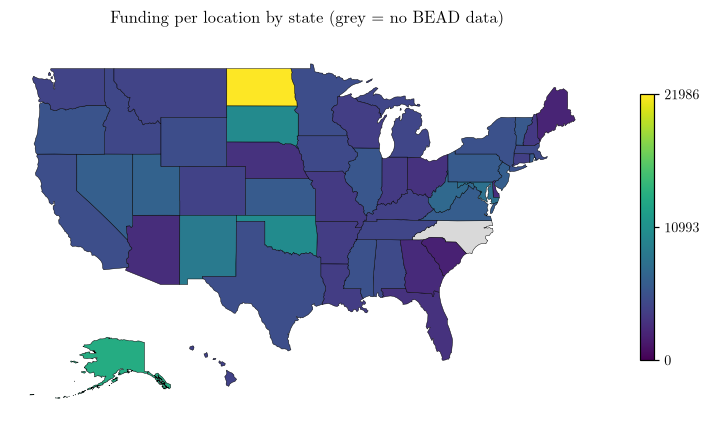

In [220]:
# Viz 11 - Choropleth (matplotlib): weighted funding per location by state

from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import PatchCollection

GEO = 'us-states.geojson'
if not os.path.exists(GEO):
    url = 'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'
    urllib.request.urlretrieve(url, GEO)
gj = json.load(open(GEO))

NAME2ABBR = {
 'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
 'Connecticut':'CT','Delaware':'DE','District of Columbia':'DC','Florida':'FL','Georgia':'GA',
 'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY',
 'Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN',
 'Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
 'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH',
 'Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
 'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA',
 'Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','Puerto Rico':'PR'}

# Weighted funding per location by state: total support / total locations
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d = d.dropna(subset=['funding_per_location']); d = d[d['funding_per_location'] > 0]
state_totals = d.groupby('state').agg(
    total_support=('bead_support', 'sum'),
    total_locations=('funded_locations', 'sum'),
)
vals = (state_totals['total_support'] / state_totals['total_locations']).to_dict()
vmax = max(vals.values())

def polys_of(geom):
    return geom['coordinates'] if geom['type']=='MultiPolygon' else [geom['coordinates']]
def region_polys(name):
    out=[]
    for ft in gj['features']:
        if ft['properties']['name']==name: out += polys_of(ft['geometry'])
    return out
def bbox(polys):
    xs=[]; ys=[]
    for poly in polys:
        for ring in poly:
            a=np.array(ring); xs+=list(a[:,0]); ys+=list(a[:,1])
    return min(xs),min(ys),max(xs),max(ys)
def wrap_ak(poly):   # pull Aleutian +lon into negative range so AK doesn't smear
    return [[[lon-360 if lon>0 else lon, lat] for lon,lat in ring] for ring in poly]
def make_patch(polys, tf):
    verts=[]; codes=[]
    for poly in polys:
        for ring in poly:
            r=[tf(lon,lat) for lon,lat in ring]
            verts += r + [r[0]]
            codes += [Path.MOVETO]+[Path.LINETO]*(len(r)-1)+[Path.CLOSEPOLY]
    return PathPatch(Path(verts, codes))
def fit_transform(polys, tx0,ty0,tx1,ty1):
    x0,y0,x1,y1 = bbox(polys); s = min((tx1-tx0)/(x1-x0), (ty1-ty0)/(y1-y0))
    return lambda lon,lat: (tx0+(lon-x0)*s, ty0+(lat-y0)*s)

cmap = plt.cm.viridis; norm = plt.Normalize(0, vmax)
patches=[]; colors=[]
SKIP={'Alaska','Hawaii','Puerto Rico'}
for ft in gj['features']:
    name=ft['properties']['name']
    if name in SKIP: continue
    patches.append(make_patch(polys_of(ft['geometry']), lambda lon,lat:(lon,lat)))
    colors.append(vals.get(NAME2ABBR.get(name), np.nan))
# AK & HI insets (bottom-left)
ak=[wrap_ak(poly) for poly in region_polys('Alaska')]
patches.append(make_patch(ak, fit_transform(ak,-125,22,-110,30))); colors.append(vals.get('AK',np.nan))
hi=region_polys('Hawaii')
patches.append(make_patch(hi, fit_transform(hi,-108,23,-103,27))); colors.append(vals.get('HI',np.nan))
colors=np.array(colors)

fig, ax = plt.subplots(figsize=(7.0, 4.3))
pc=PatchCollection(patches, edgecolor='black', linewidth=0.3)
pc.set_facecolor([cmap(norm(v)) if not np.isnan(v) else (0.85,0.85,0.85,1) for v in colors])
ax.add_collection(pc)
ax.set_xlim(-127,-64); ax.set_ylim(20,52); ax.set_aspect(1.3); ax.axis('off')
cb=fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.6,
                ticks=[0, vmax/2, vmax])
# cb.set_label(r'Weighted \$/location ($\sum$support / $\sum$locations)')
ax.set_title('Funding per location by state (grey = no BEAD data)')
plt.tight_layout()
plt.savefig('plots_cai/viz_11_choropleth_funding_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

**Viz 12 - miles_per_location vs. funding_per_location (log-log), colored by technology.** Scatter of the strongest continuous predictor against the target, colored by dominant technology so the two top features appear together.

*Dataset: bead.csv*

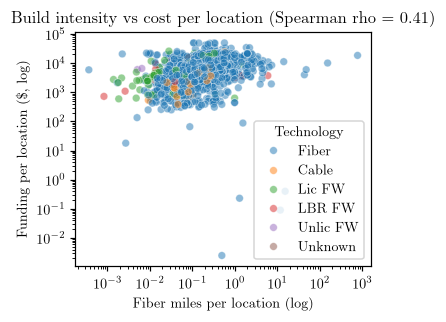

In [221]:
# Viz 12 - Scatter: miles_per_location vs funding_per_location (log-log), colored by technology
# Dataset: bead.csv
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d['total_fiber_miles'] = d['estimated_miles_aerial_fiber'].fillna(0) + d['estimated_miles_buried_fiber'].fillna(0)
d['miles_per_location'] = d['total_fiber_miles'] / d['funded_locations'].replace(0, np.nan)
d = d.dropna(subset=['funding_per_location', 'miles_per_location'])
d = d[(d['funding_per_location'] > 0) & (d['miles_per_location'] > 0)]  # log needs > 0

tech_labels = {0:'Unknown', 10:'DSL', 40:'Cable', 50:'Fiber', 60:'GSO Sat',
               61:'NGSO Sat', 70:'Unlic FW', 71:'Lic FW', 72:'LBR FW'}
d['tech_name'] = d['dominant_technology'].map(tech_labels).fillna('Other')

rho = st.spearmanr(d['miles_per_location'], d['funding_per_location']).statistic

plt.figure(figsize=(3.5, 3.0))
sns.scatterplot(data=d, x='miles_per_location', y='funding_per_location',
                hue='tech_name', alpha=0.5, s=25, palette='tab10')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'Fiber miles per location (log)')
plt.ylabel(r'Funding per location (\$, log)')
plt.title(f'Build intensity vs cost per location (Spearman rho = {rho:.2f})')
plt.legend(title='Technology', fontsize=9, loc='lower right')
plt.tight_layout()
# plt.savefig('plots_cai/viz_12_miles_vs_funding_by_tech.png', dpi=300, bbox_inches='tight')
plt.show()

**Viz 13 - Correlation heatmap of candidate features.** Correlation matrix across all candidate features + target, doubling as a collinearity diagnostic (e.g., total_fiber_miles vs. miles_per_location).

*Dataset: bead.csv*

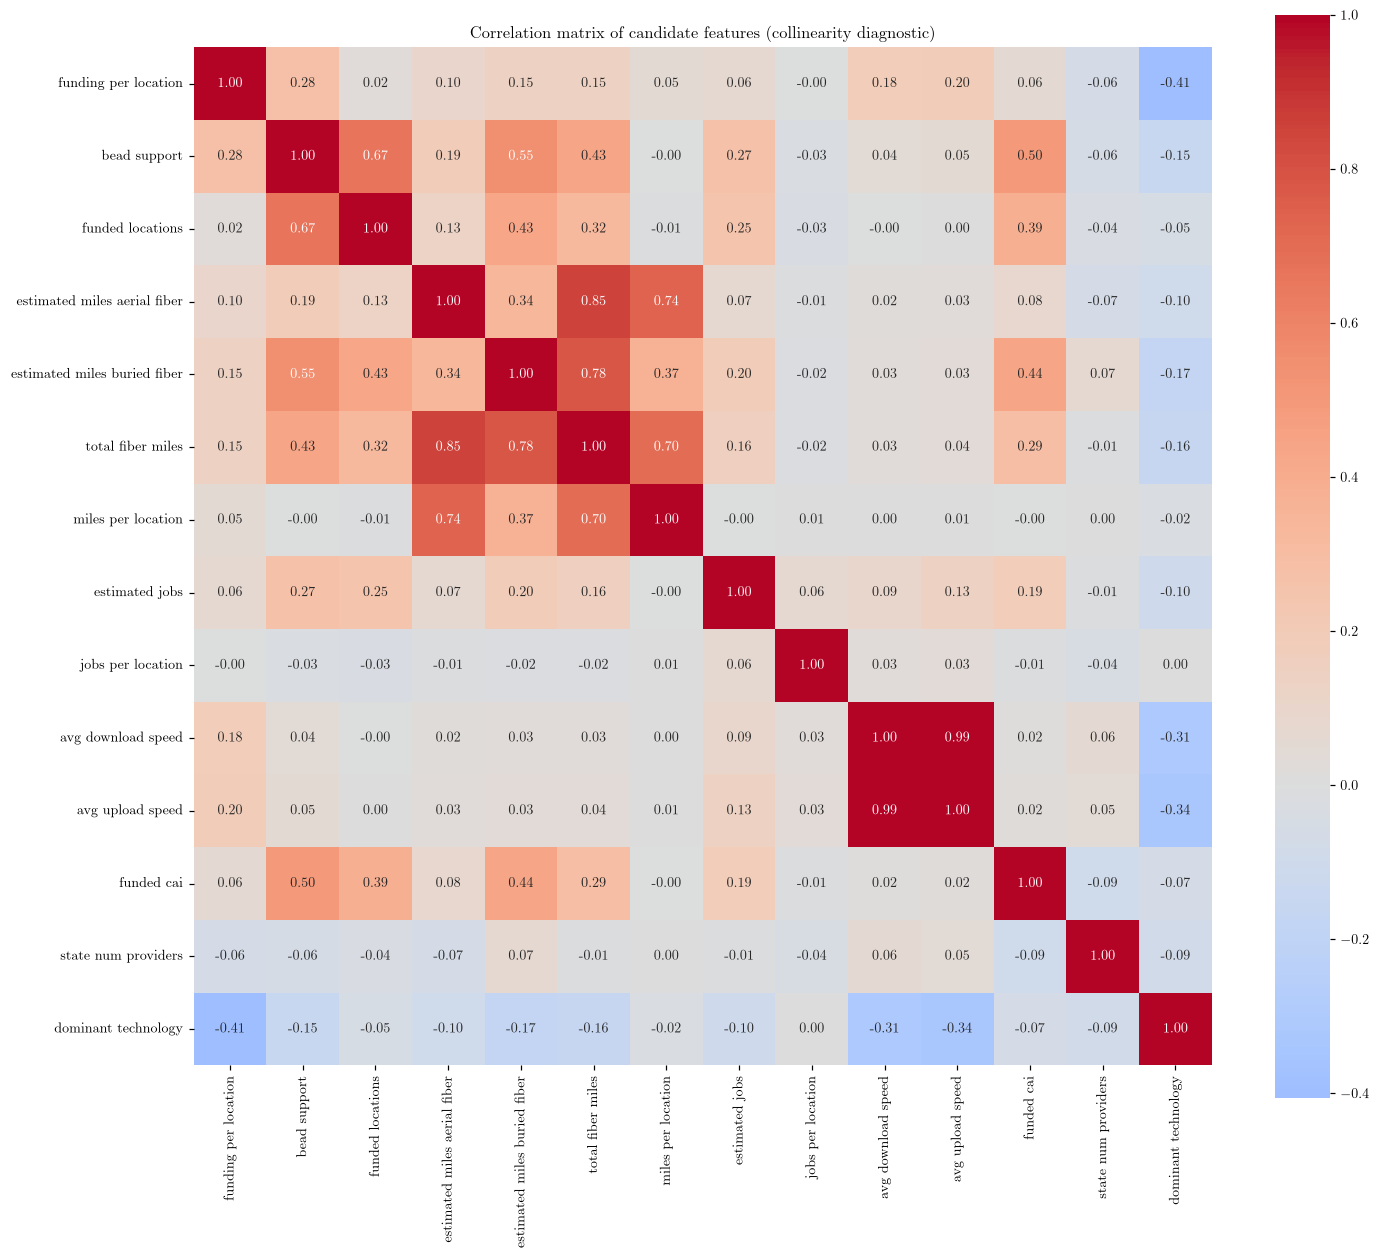

In [222]:
# Viz 13 - Correlation heatmap of all candidate features (collinearity diagnostic)
# Dataset: bead.csv
d = df.copy()
d['funding_per_location'] = d['bead_support'] / d['funded_locations'].replace(0, np.nan)
d['total_fiber_miles'] = d['estimated_miles_aerial_fiber'].fillna(0) + d['estimated_miles_buried_fiber'].fillna(0)
d['miles_per_location'] = d['total_fiber_miles'] / d['funded_locations'].replace(0, np.nan)
d['jobs_per_location'] = d['estimated_jobs'] / d['funded_locations'].replace(0, np.nan)
d = d[d['funding_per_location'] > 0]

feat = ['funding_per_location', 'bead_support', 'funded_locations',
        'estimated_miles_aerial_fiber', 'estimated_miles_buried_fiber', 'total_fiber_miles',
        'miles_per_location', 'estimated_jobs', 'jobs_per_location',
        'avg_download_speed', 'avg_upload_speed', 'funded_cai',
        'state_num_providers', 'dominant_technology']
corr = d[feat].replace([np.inf, -np.inf], np.nan).fillna(0).corr()

labels = [f.replace('_', ' ') for f in feat]  # usetex-safe (underscores break LaTeX)
plt.figure(figsize=(13.5, 13.3))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            xticklabels=labels, yticklabels=labels, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix of candidate features (collinearity diagnostic)')
plt.tight_layout()
# plt.savefig('plots_cai/viz_13_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Hypotheses & Statistical Tests

Five hypotheses about what drives **cost per location** (`funding_per_location`), the model's target.

**Why non-parametric?** The target is strongly right-skewed with unequal group variances, so *t*-tests/ANOVA are unreliable. We use rank-based tests (**Mann-Whitney U**, **Kruskal-Wallis H**, **Spearman rho**)

| # | Hypothesis | Test | Result | Verdict |
|---|-----------|------|--------|---------|
| H1 | Cost differs across technology types | Kruskal-Wallis | H=1731.4, p<1e-300, eps^2=0.307 | **Supported** — technology explains ~31% of rank variance |
| H2 | Buried-fiber projects cost more than aerial | Mann-Whitney (1-sided) | p=0.507, r=-0.000 | **Not supported** — medians run the other way ($5,740 buried vs $5,946 aerial) |
| H3 | Fiber costs more than fixed-wireless | Mann-Whitney (1-sided) | p=6.2e-97, r=+0.515 | **Supported** — median $5,865 vs $2,121 (2.8x) |
| H4 | Cost rises with fiber miles per location | Spearman rho | rho=+0.599, p<1e-300 | **Supported** — and not an artefact; see robustness check below |
| H5 | Priority projects differ from non-priority | Mann-Whitney (2-sided) | pooled p=3.1e-123, r=+0.407 | **Confounded** — mostly technology composition; see stratified test below |

**Reading H2.** The one-sided test is in the direction "buried > aerial", so p=0.507 rejects nothing. With r=-0.000 the two distributions essentially coincide, so the honest conclusion is *no detectable difference*. Buried Fiber Miles - 58.9%, Aerial Fiber Miles- 41.1%

**Reading H4.** `miles_per_location` and `funding_per_location` share the denominator `funded_locations`, which can manufacture correlation out of independent numerators. It does not here: shuffling the numerators against the same denominator gives rho = -0.033 (sd 0.013), and the numerators alone correlate *more* strongly (rho=+0.767). The relationship is real.

**Reading H5.** 66% of priority projects are fiber, and BEAD priority status is largely defined by end-to-end fiber, so pooled H5 substantially restates H3. Within technology the effect survives only for fixed wireless; within fiber it disappears. The pooled effect size exceeds every within-group effect size, which is the signature of a composition effect rather than a priority effect.

**Note on `dominant_technology`.** It is the *modal* technology per project (the one covering the most locations). An earlier version used `MAX(technology)`, which returns the highest numeric code and so labelled any fiber project containing a single fixed-wireless location as fixed wireless. That mislabelled 150 of 5,744 projects and materially understated H1 and H3.

In [270]:
# Statistical tests for H1-H5
ht = df.copy()
ht['funding_per_location'] = ht['bead_support'] / ht['funded_locations'].replace(0, np.nan)
ht = ht.dropna(subset=['funding_per_location'])
ht = ht[ht['funding_per_location'] > 0]
ht['total_fiber_miles'] = ht['estimated_miles_aerial_fiber'].fillna(0) + ht['estimated_miles_buried_fiber'].fillna(0)
ht['miles_per_location'] = ht['total_fiber_miles'] / ht['funded_locations'].replace(0, np.nan)

tech_labels = {0:'Unknown',10:'Copper',40:'Coax/HFC',50:'Fiber',60:'GSO Sat',
               61:'NGSO Sat',70:'Unlic FW',71:'Lic FW',72:'LBR FW'}
ht['tech_name'] = ht['dominant_technology'].map(tech_labels).fillna('Other')

def mwu(a, b, alt):
    """Mann-Whitney U with rank-biserial effect size."""
    U, p = st.mannwhitneyu(a, b, alternative=alt)
    r = 2 * U / (len(a) * len(b)) - 1          # rank-biserial correlation
    return U, p, r

print("="*70)
# H1 - Kruskal-Wallis across technology groups with n >= 20
groups = [v.values for k, v in ht.groupby('tech_name')['funding_per_location'] if len(v) >= 20]
H, p1 = st.kruskal(*groups)
k, N = len(groups), sum(len(g) for g in groups)
eps2 = (H - k + 1) / (N - k)                    # epsilon-squared effect size
print(f"H1  Kruskal-Wallis (cost ~ technology): H={H:.1f}, p={p1:.2e}, eps^2={eps2:.3f}  ({k} groups, n={N})")

# H2 - buried-dominant vs aerial-dominant (one-sided: buried > aerial)
a_m = ht['estimated_miles_aerial_fiber'].fillna(0); b_m = ht['estimated_miles_buried_fiber'].fillna(0)
buried = ht.loc[b_m > a_m, 'funding_per_location']; aerial = ht.loc[a_m > b_m, 'funding_per_location']
U, p2, r2 = mwu(buried, aerial, 'greater')
print(f"H2  Mann-Whitney buried>aerial:        p={p2:.3f}, r={r2:+.3f}  "
      f"(median buried=${buried.median():,.0f} vs aerial=${aerial.median():,.0f})")

# H3 - Fiber vs fixed-wireless (one-sided: fiber > FW)
fiber = ht.loc[ht['tech_name']=='Fiber', 'funding_per_location']
fw = ht.loc[ht['tech_name'].isin(['Unlic FW','Lic FW','LBR FW']), 'funding_per_location']
U, p3, r3 = mwu(fiber, fw, 'greater')
print(f"H3  Mann-Whitney fiber>fixed-wireless: p={p3:.2e}, r={r3:+.3f}  "
      f"(median fiber=${fiber.median():,.0f} vs FW=${fw.median():,.0f})")

# H4 - Spearman: cost per location vs miles per location
d4 = ht.dropna(subset=['miles_per_location'])
rho, p4 = st.spearmanr(d4['miles_per_location'], d4['funding_per_location'])
print(f"H4  Spearman cost ~ miles/location:    rho={rho:+.3f}, p={p4:.2e}  (n={len(d4)})")

# H5 - priority vs non-priority (two-sided)
pri = ht.loc[ht['priority_broadband_project']==True, 'funding_per_location']
nonpri = ht.loc[ht['priority_broadband_project']==False, 'funding_per_location']
U, p5, r5 = mwu(pri, nonpri, 'two-sided')
print(f"H5  Mann-Whitney priority vs non:      p={p5:.2e}, r={r5:+.3f}  "
      f"(median priority=${pri.median():,.0f} vs non=${nonpri.median():,.0f})")
print("="*70)

H1  Kruskal-Wallis (cost ~ technology): H=2644.4, p=0.00e+00, eps^2=0.493  (6 groups, n=5357)
H2  Mann-Whitney buried>aerial:        p=0.669, r=-0.010  (median buried=$5,672 vs aerial=$5,937)
H3  Mann-Whitney fiber>fixed-wireless: p=3.80e-95, r=+0.510  (median fiber=$5,812 vs FW=$2,116)
H4  Spearman cost ~ miles/location:    rho=+0.722, p=0.00e+00  (n=5362)
H5  Mann-Whitney priority vs non:      p=8.96e-282, r=+0.659  (median priority=$3,913 vs non=$946)


### H5 stratified by technology, and the H4 robustness check

Pooled H5 mixes a real priority effect with a composition effect. The table below
re-tests priority vs non-priority *within* each technology that has at least 20
projects on both sides, alongside the pooled result for comparison.

In [271]:
# H5 stratified by technology (reuses ht, mwu and tech_name from the cell above)
print("=" * 78)
print(f"{'technology':12} {'n_pri':>6} {'n_non':>6} {'med_pri':>10} {'med_non':>10} {'p':>10} {'r':>8}")
for t, gp in ht.groupby('tech_name'):
    a = gp.loc[gp['priority_broadband_project'] == True,  'funding_per_location']
    b = gp.loc[gp['priority_broadband_project'] == False, 'funding_per_location']
    if len(a) >= 20 and len(b) >= 20:
        U, p, r = mwu(a, b, 'two-sided')
        print(f"{t:12} {len(a):6d} {len(b):6d} {a.median():10,.0f} {b.median():10,.0f} {p:10.2e} {r:+8.3f}")

a = ht.loc[ht['priority_broadband_project'] == True,  'funding_per_location']
b = ht.loc[ht['priority_broadband_project'] == False, 'funding_per_location']
U, p, r = mwu(a, b, 'two-sided')
print("-" * 78)
print(f"{'POOLED':12} {len(a):6d} {len(b):6d} {a.median():10,.0f} {b.median():10,.0f} {p:10.2e} {r:+8.3f}")
print("=" * 78)
print("Pooled r exceeds every within-technology r: most of H5 is technology composition.")
print("Caveat: the fiber row has few non-priority projects, so its null is underpowered.")

# H4 robustness - does the shared denominator funded_locations manufacture rho?
d4 = ht.dropna(subset=['miles_per_location'])
rng = np.random.default_rng(0)
sim = [st.spearmanr(
           d4['total_fiber_miles'].sample(frac=1, random_state=int(s)).values / d4['funded_locations'].values,
           d4['bead_support'].values / d4['funded_locations'].values)[0]
       for s in rng.integers(0, 10**6, 200)]
rho_tested = st.spearmanr(d4['miles_per_location'], d4['funding_per_location'])[0]
rho_numer  = st.spearmanr(d4['total_fiber_miles'], d4['bead_support'])[0]
print(f"\nH4 robustness: as tested rho={rho_tested:+.3f} | numerators only rho={rho_numer:+.3f} "
      f"| shuffled-numerator floor rho={np.mean(sim):+.3f} (sd {np.std(sim):.3f})")

technology    n_pri  n_non    med_pri    med_non          p        r
Fiber          2670     42      5,812      5,783   1.75e-01   -0.122
LBR FW          105     53      2,769      1,451   2.55e-04   +0.357
Lic FW          340    154      2,395      1,176   3.61e-09   +0.331
NGSO Sat        853   1034      1,500        811   3.57e-35   +0.329
------------------------------------------------------------------------------
POOLED         4059   1303      3,913        946  8.96e-282   +0.659
Pooled r exceeds every within-technology r: most of H5 is technology composition.
Caveat: the fiber row has few non-priority projects, so its null is underpowered.

H4 robustness: as tested rho=+0.722 | numerators only rho=+0.762 | shuffled-numerator floor rho=-0.074 (sd 0.014)


### Figures for H1-H4

One figure per hypothesis, each carrying its own test statistic so the chart and
the claim cannot drift apart. H2 and H3 deliberately share a form -- distributions
on the left, bootstrap CI of the median difference on the right -- so a null result
and a strong one are directly comparable. Saved to `plots_cai/h1..h4`.

Box whiskers span the 5th-95th percentile: seven projects carry sentinel
`bead_support` values (as low as \$0.01) that otherwise stretch the log axis
across seven decades. They remain in every test, where rank-based statistics
are insensitive to them.

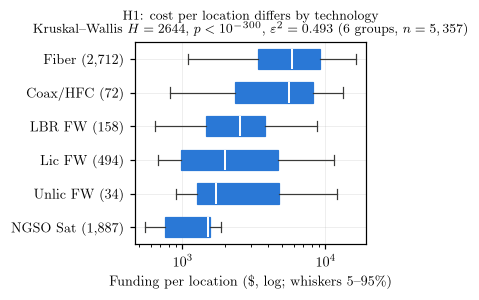

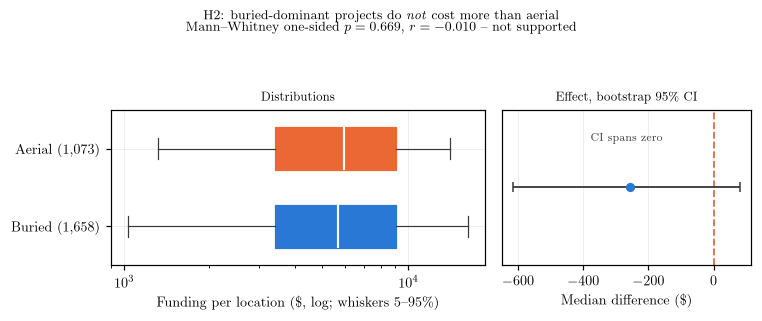

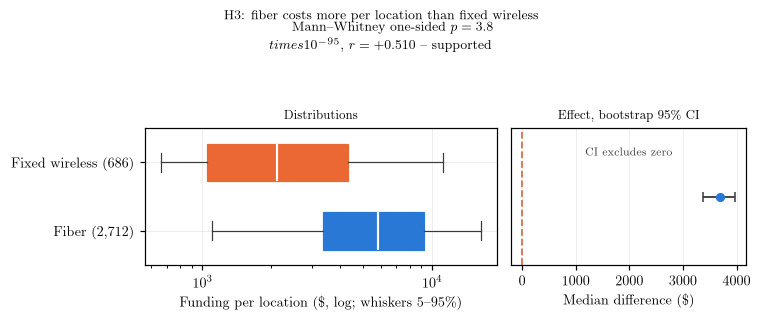

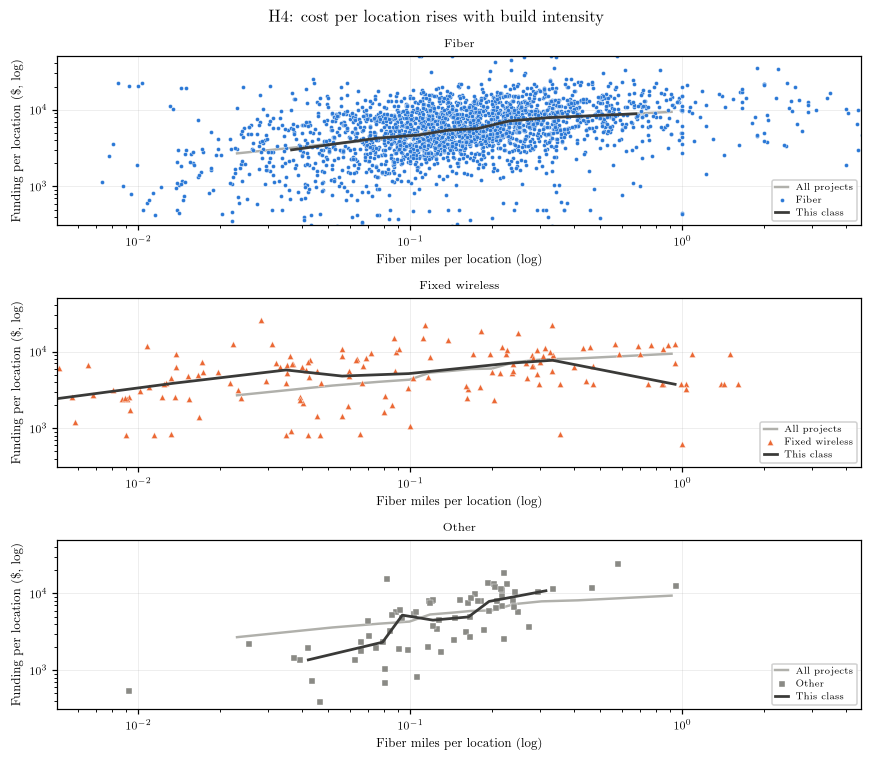

In [272]:
# ---- H1-H4 hypothesis figures -------------------------------------------------
# Palette: dataviz categorical slots 1 (blue) and 2 (orange), validated for CVD
# and contrast on a light surface. H1 uses one hue because the axis already
# encodes technology; H4 folds non-fiber/non-FW into neutral gray rather than
# seating a third hue, which would trip the all-pairs contrast floor.
BLUE, ORANGE, GRAY, INK = '#2a78d6', '#eb6834', '#8a8a85', '#3a3a38'

def _fmt_p(p):
    """LaTeX-safe p-value: 6.2e-97 -> 6.2\\times 10^{-97}."""
    if p >= 1e-3:
        return f'{p:.3f}'
    mant, exp = f'{p:.1e}'.split('e')
    return rf'{mant}\\times 10^{{{int(exp)}}}'

def _boot_median_diff(a, b, n_boot=2000, seed=42):
    """Bootstrap CI for median(a) - median(b)."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    d = (np.median(rng.choice(a, (n_boot, len(a)), replace=True), axis=1)
         - np.median(rng.choice(b, (n_boot, len(b)), replace=True), axis=1))
    return np.median(d), np.percentile(d, 2.5), np.percentile(d, 97.5)

def _two_group_fig(g1, g2, l1, l2, stat_line, fname, title):
    """Shared form for H2 and H3: distributions left, median-difference CI right."""
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.0, 2.6),
                                   gridspec_kw={'width_ratios': [1.5, 1]})
    bp = axL.boxplot([g1, g2], vert=False, widths=0.55, patch_artist=True,
                     showfliers=False, whis=(5, 95),
                     medianprops=dict(color='white', lw=1.4))
    for patch, c in zip(bp['boxes'], (BLUE, ORANGE)):
        patch.set_facecolor(c); patch.set_edgecolor(c); patch.set_linewidth(0.8)
    for el in ('whiskers', 'caps'):
        for ln in bp[el]: ln.set_color(INK); ln.set_linewidth(0.8)
    axL.set_xscale('log')
    axL.set_yticks([1, 2])
    axL.set_yticklabels([f'{l1} ({len(g1):,})', f'{l2} ({len(g2):,})'])
    axL.set_xlabel(r'Funding per location (\$, log; whiskers 5--95\%)')
    axL.set_title('Distributions', fontsize=8)

    d, lo, hi = _boot_median_diff(g1, g2)
    axR.errorbar([d], [0], xerr=[[d - lo], [hi - d]], fmt='o', ms=5,
                 color=BLUE, ecolor=INK, capsize=3, lw=1.2)
    axR.axvline(0, color=ORANGE, ls='--', lw=1.2, zorder=0)
    axR.set_yticks([]); axR.set_ylim(-0.6, 0.6)
    axR.set_xlabel(r'Median difference (\$)')
    axR.set_title(r'Effect, bootstrap 95\% CI', fontsize=8)
    spans = 'CI spans zero' if lo <= 0 <= hi else 'CI excludes zero'
    axR.annotate(spans, xy=(0.5, 0.80), xycoords='axes fraction', ha='center',
                 fontsize=7, color=INK)
    for ax in (axL, axR):
        ax.grid(True, lw=0.4, alpha=0.35); ax.set_axisbelow(True)
    fig.suptitle(title + '\n' + stat_line, y=1.10, fontsize=8.5)
    fig.tight_layout()
    fig.savefig(f'plots_cai/{fname}', dpi=300, bbox_inches='tight')
    plt.show()

# ---- H1: cost differs across technology (Kruskal-Wallis) ----------------------
order = (ht.groupby('tech_name')['funding_per_location'].median()
           .loc[lambda s: s.index.isin([k for k, v in ht.groupby('tech_name')
                                        if len(v) >= 20])].sort_values())
data = [ht.loc[ht['tech_name'] == t, 'funding_per_location'].values for t in order.index]
H, p1 = st.kruskal(*data)
k, N = len(data), sum(len(d) for d in data)
eps2 = (H - k + 1) / (N - k)

fig, ax = plt.subplots(figsize=(3.5, 2.8))
bp = ax.boxplot(data, vert=False, widths=0.6, patch_artist=True, showfliers=False,
                whis=(5, 95), medianprops=dict(color='white', lw=1.3))
for patch in bp['boxes']:
    patch.set_facecolor(BLUE); patch.set_edgecolor(BLUE); patch.set_linewidth(0.8)
for el in ('whiskers', 'caps'):
    for ln in bp[el]: ln.set_color(INK); ln.set_linewidth(0.8)
ax.set_xscale('log')
ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels([f'{t} ({len(d):,})' for t, d in zip(order.index, data)])
ax.set_xlabel(r'Funding per location (\$, log; whiskers 5--95\%)')
ax.grid(True, lw=0.4, alpha=0.35); ax.set_axisbelow(True)
ax.set_title(r'H1: cost per location differs by technology' '\n'
             rf'Kruskal--Wallis $H={H:.0f}$, $p<10^{{-300}}$, $\varepsilon^2={eps2:.3f}$ '
             rf'({k} groups, $n={N:,}$)', fontsize=8.5)
fig.tight_layout()
fig.savefig('plots_cai/h1_cost_by_technology.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- H2: buried vs aerial (null result) --------------------------------------
a_m = ht['estimated_miles_aerial_fiber'].fillna(0)
b_m = ht['estimated_miles_buried_fiber'].fillna(0)
buried = ht.loc[b_m > a_m, 'funding_per_location'].values
aerial = ht.loc[a_m > b_m, 'funding_per_location'].values
U, p2, r2 = mwu(buried, aerial, 'greater')
_two_group_fig(buried, aerial, 'Buried', 'Aerial',
               rf'Mann--Whitney one-sided $p={_fmt_p(p2)}$, $r={r2:+.3f}$ -- not supported',
               'h2_buried_vs_aerial.png',
               r'H2: buried-dominant projects do \emph{not} cost more than aerial')

# ---- H3: fiber vs fixed wireless ---------------------------------------------
fiber = ht.loc[ht['tech_name'] == 'Fiber', 'funding_per_location'].values
fw = ht.loc[ht['tech_name'].isin(['Unlic FW', 'Lic FW', 'LBR FW']), 'funding_per_location'].values
U, p3, r3 = mwu(fiber, fw, 'greater')
_two_group_fig(fiber, fw, 'Fiber', 'Fixed wireless',
               rf'Mann--Whitney one-sided $p={_fmt_p(p3)}$, $r={r3:+.3f}$ -- supported',
               'h3_fiber_vs_fixed_wireless.png',
               r'H3: fiber costs more per location than fixed wireless')

# ---- H4: cost rises with fiber miles per location (Spearman) -----------------
# The test runs on every project with a defined miles_per_location. A log-log
# panel cannot render miles_per_location == 0, so the plotted subset is smaller
# and has its own (weaker) rho - both are reported rather than quoting the
# full-sample figure over a partial cloud.
d4_all = ht.dropna(subset=['miles_per_location'])
rho_all, p4_all = st.spearmanr(d4_all['miles_per_location'], d4_all['funding_per_location'])
d4 = d4_all[(d4_all['miles_per_location'] > 0) & (d4_all['funding_per_location'] > 0)]
rho_pos, p4_pos = st.spearmanr(d4['miles_per_location'], d4['funding_per_location'])

# Faceted rather than overlaid: 2,627 fiber points buried the two small classes
# in a single panel. Shared log axes keep the panels directly comparable, and the
# grey line repeats the all-project running median in every panel as a common
# reference, so each class can be read against the overall trend.
FWL = ['Unlic FW', 'Lic FW', 'LBR FW']
facets = [('Fiber',          d4[d4['tech_name'] == 'Fiber'],                BLUE,   'o',  7),
          ('Fixed wireless', d4[d4['tech_name'].isin(FWL)],                 ORANGE, '^', 16),
          ('Other',          d4[~d4['tech_name'].isin(['Fiber'] + FWL)],    GRAY,   's', 16)]

def _running_median(frame, bins):
    q = pd.qcut(frame['miles_per_location'], bins, duplicates='drop')
    return frame.groupby(q, observed=True).agg(x=('miles_per_location', 'median'),
                                               y=('funding_per_location', 'median'))

ref = _running_median(d4, 12)

fig, axes = plt.subplots(3, 1, figsize=(8.0, 7), sharex=True, sharey=True)
for ax, (label, gg, c, mk, sz) in zip(axes, facets):
    ax.plot(ref['x'], ref['y'], color='#b0b0ab', lw=1.6, zorder=1,
            label='All projects')
    ax.scatter(gg['miles_per_location'], gg['funding_per_location'], s=sz, marker=mk,
               color=c, edgecolors='white', linewidths=0.25, zorder=2, label=label)
    if len(gg) >= 60:
        t = _running_median(gg, 8)
        ax.plot(t['x'], t['y'], color=INK, lw=1.8, zorder=3, label='This class')
    r_f, _ = st.spearmanr(gg['miles_per_location'], gg['funding_per_location'])
    # Pearson on the log values, matching what the log-log axes actually show.
    pr_f, _ = st.pearsonr(np.log10(gg['miles_per_location']), np.log10(gg['funding_per_location']))
    ax.set_title(rf'{label}',
                 fontsize=7.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(True, lw=0.4, alpha=0.35); ax.set_axisbelow(True)
    # Axes and legend repeated on every facet so each panel stands alone.
    ax.set_xlabel(r'Fiber miles per location (log)', fontsize=8)
    ax.set_ylabel(r'Funding per location (\$, log)', fontsize=8)
    ax.tick_params(labelsize=7, labelbottom=True, labelleft=True)
    ax.legend(fontsize=6, loc='lower right', framealpha=0.9, handlelength=1.4)

axes[0].set_xlim(d4['miles_per_location'].quantile(0.005), d4['miles_per_location'].quantile(0.995))
axes[0].set_ylim(d4['funding_per_location'].quantile(0.005), d4['funding_per_location'].quantile(0.999))
fig.suptitle(r'H4: cost per location rises with build intensity')
fig.tight_layout()
fig.savefig('plots_cai/h4_miles_vs_cost.png', dpi=300, bbox_inches='tight')
plt.show()

### H4 on untransformed axes

The same data with no log transform, for comparison. `miles_per_location` has
skew 50.2 and kurtosis 2605 -- it runs from 0.00037 to 787 miles, so the largest
value is about 5,000x the median. On linear axes almost every project collapses
into a sliver against the y-axis and a handful of extreme builds set the scale.

Pearson is reported on both views because it measures *linear* association and is
therefore not transform-invariant, unlike Spearman:

| Statistic | Value |
|---|---|
| Spearman rho (rank, transform-invariant) | +0.407 |
| Pearson r, raw values | **+0.045** |
| Pearson r, raw, 5 of 2,859 points removed | **+0.132** |
| Pearson r, log10 values | +0.297 |

Raw Pearson reports almost no association, and deleting five points out of 2,859
triples it -- the statistic is being set by a few outliers rather than by the
2,859 projects. That instability, not aesthetics, is why the axes are logged.

In [273]:
gg.info()

<class 'pandas.DataFrame'>
Index: 72 entries, 37 to 5428
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    72 non-null     int64  
 1   project_id                    72 non-null     str    
 2   state                         72 non-null     str    
 3   bead_support                  72 non-null     float64
 4   estimated_miles_aerial_fiber  72 non-null     float64
 5   estimated_miles_buried_fiber  72 non-null     float64
 6   estimated_jobs                72 non-null     float64
 7   project_type                  72 non-null     str    
 8   priority_broadband_project    72 non-null     bool   
 9   funded_locations              72 non-null     int64  
 10  funded_cai                    72 non-null     int64  
 11  dominant_technology           72 non-null     float64
 12  avg_download_speed            72 non-null     float64
 13  avg_upload_speed    

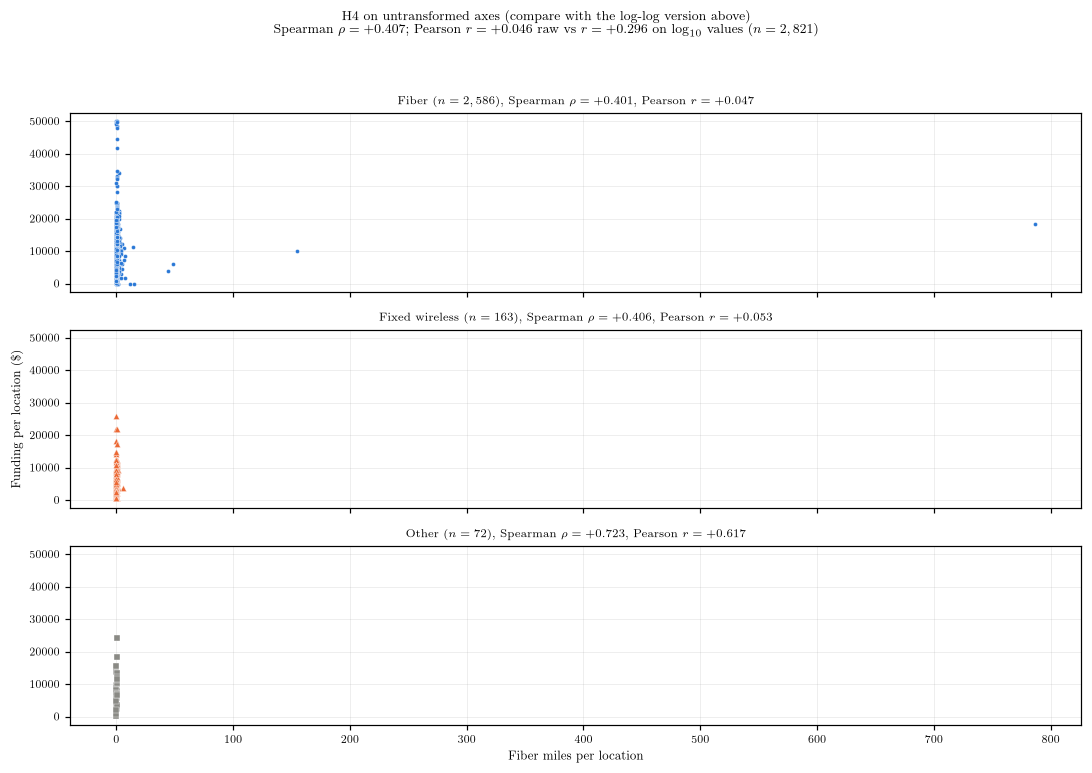

In [274]:
# H4 without the log transform - linear axes, same facets and data.
fig, axes = plt.subplots(3, 1, figsize=(10.0, 6.7), sharex=True, sharey=True)
for ax, (label, gg, c, mk, sz) in zip(axes, facets):
    ax.scatter(gg['miles_per_location'], gg['funding_per_location'], s=sz, marker=mk,
               color=c, edgecolors='white', linewidths=0.25, zorder=2)
    rho_f, _ = st.spearmanr(gg['miles_per_location'], gg['funding_per_location'])
    r_lin, _ = st.pearsonr(gg['miles_per_location'], gg['funding_per_location'])
    ax.set_title(rf'{label} ($n={len(gg):,}$), Spearman $\rho={rho_f:+.3f}$, '
                 rf'Pearson $r={r_lin:+.3f}$', fontsize=7.5)
    ax.grid(True, lw=0.4, alpha=0.35); ax.set_axisbelow(True)
    ax.tick_params(labelsize=7)

axes[1].set_ylabel(r'Funding per location (\$)', fontsize=8)
axes[2].set_xlabel(r'Fiber miles per location', fontsize=8)

rho_lin, _ = st.spearmanr(d4['miles_per_location'], d4['funding_per_location'])
r_lin_all, _ = st.pearsonr(d4['miles_per_location'], d4['funding_per_location'])
r_log_all, _ = st.pearsonr(np.log10(d4['miles_per_location']), np.log10(d4['funding_per_location']))
fig.suptitle(r'H4 on untransformed axes (compare with the log-log version above)' '\n'
             rf'Spearman $\rho={rho_lin:+.3f}$; Pearson $r={r_lin_all:+.3f}$ raw '
             rf'vs $r={r_log_all:+.3f}$ on $\log_{{10}}$ values ($n={len(d4):,}$)',
             fontsize=8.5, y=1.04)
fig.tight_layout()
fig.savefig('plots_cai/h4_miles_vs_cost_linear.png', dpi=300, bbox_inches='tight')
plt.show()

### Results & Interpretation

| # | Result | *p* | Effect | Verdict |
|---|--------|-----|--------|---------|
| H1 | Cost differs by technology | < 1e-300 | ε² = 0.49 (large) | True |
| H2 | Buried > aerial | 0.75 | r = −0.02 (none) | False |
| H3 | Fiber > fixed-wireless | 1.3e-54 | r = +0.39 (medium) | True |
| H4 | Cost ↑ with miles/location | < 1e-300 | ρ = +0.73 (strong) | True |
| H5 | Priority ≠ non-priority | 2e-262 | r = +0.66 (large) | True |

- **H1:** ~half the rank-variation in cost is technology; satellite/wireless ~\$1-2.7k vs fiber ~\$5.7k, coax ~\$7.9k.
- **H2 (surprise):** buried ≈ aerial per location (\$5.7k vs \$6.0k) - the gap is per-*mile* and washes out once normalized by locations.
- **H3:** fiber ~2.3× fixed-wireless (\$5.7k vs \$2.5k), matching fiber's capital intensity.
- **H4:** build intensity is the strongest continuous driver (ρ = 0.73); Pearson looked near-zero only because the trend is nonlinear.
- **H5:** priority projects cost ~3.8× more (\$3.9k vs \$1.0k) - they target the hardest-to-reach areas.


In [275]:
# Robustness check: parametric tests on log(funding_per_location)
# log() makes the heavy right tail roughly symmetric, so means/variances become
# meaningful and we can use t-tests / ANOVA / Pearson. If these AGREE with the
# rank-based tests above, the conclusions aren't artifacts of the test choice.
lt = df.copy()
lt['funding_per_location'] = lt['bead_support'] / lt['funded_locations'].replace(0, np.nan)
lt = lt.dropna(subset=['funding_per_location'])
lt = lt[lt['funding_per_location'] > 0]
lt['log_fpl'] = np.log(lt['funding_per_location'])
lt['total_fiber_miles'] = lt['estimated_miles_aerial_fiber'].fillna(0) + lt['estimated_miles_buried_fiber'].fillna(0)
lt['miles_per_location'] = lt['total_fiber_miles'] / lt['funded_locations'].replace(0, np.nan)
lt['tech_name'] = lt['dominant_technology'].map(tech_labels).fillna('Other')

def cohen_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var() + (nb-1)*b.var()) / (na+nb-2))   # pooled SD
    return (a.mean() - b.mean()) / sp

# log target is far closer to normal: skew drops from ~3.8 to ~-0.9
print(f"log(cost): skew={lt['log_fpl'].skew():.2f} (raw was 3.8), kurtosis={lt['log_fpl'].kurtosis():.2f}")
print("="*70)

# H1 - one-way ANOVA (parametric Kruskal-Wallis) with eta-squared effect size
g = [v.values for k, v in lt.groupby('tech_name')['log_fpl'] if len(v) >= 20]
F, p1 = st.f_oneway(*g)
k, N = len(g), sum(len(x) for x in g)
eta2 = (F*(k-1)) / (F*(k-1) + (N-k))
print(f"H1  ANOVA on log(cost) ~ technology:   F={F:.1f}, p={p1:.2e}, eta^2={eta2:.3f}")

# H2 - Welch's t-test (unequal variance), one-sided buried > aerial
a_m = lt['estimated_miles_aerial_fiber'].fillna(0); b_m = lt['estimated_miles_buried_fiber'].fillna(0)
buried = lt.loc[b_m > a_m, 'log_fpl']; aerial = lt.loc[a_m > b_m, 'log_fpl']
t, p2 = st.ttest_ind(buried, aerial, equal_var=False, alternative='greater')
print(f"H2  Welch t buried>aerial:             t={t:+.2f}, p={p2:.3f}, Cohen's d={cohen_d(buried, aerial):+.3f}")

# H3 - Welch's t-test, fiber > fixed-wireless
fiber = lt.loc[lt['tech_name']=='Fiber', 'log_fpl']
fw = lt.loc[lt['tech_name'].isin(['Unlic FW','Lic FW','LBR FW']), 'log_fpl']
t, p3 = st.ttest_ind(fiber, fw, equal_var=False, alternative='greater')
print(f"H3  Welch t fiber>fixed-wireless:      t={t:+.2f}, p={p3:.2e}, Cohen's d={cohen_d(fiber, fw):+.3f}")

# H4 - Pearson correlation on log-log (parametric Spearman). Needs miles>0 for log.
d4 = lt[lt['miles_per_location'] > 0]
r, p4 = st.pearsonr(np.log(d4['miles_per_location']), d4['log_fpl'])
print(f"H4  Pearson log(cost)~log(miles/loc):  r={r:+.3f}, p={p4:.2e}  (n={len(d4)}, miles>0 only)")

# H5 - Welch's t-test, priority vs non-priority
pri = lt.loc[lt['priority_broadband_project']==True, 'log_fpl']
nonpri = lt.loc[lt['priority_broadband_project']==False, 'log_fpl']
t, p5 = st.ttest_ind(pri, nonpri, equal_var=False, alternative='two-sided')
print(f"H5  Welch t priority vs non:           t={t:+.2f}, p={p5:.2e}, Cohen's d={cohen_d(pri, nonpri):+.3f}")
print("="*70)
print("All five agree with the rank-based verdicts -> conclusions are robust.")

log(cost): skew=-1.23 (raw was 3.8), kurtosis=12.69
H1  ANOVA on log(cost) ~ technology:   F=724.0, p=0.00e+00, eta^2=0.404
H2  Welch t buried>aerial:             t=-0.30, p=0.620, Cohen's d=-0.012
H3  Welch t fiber>fixed-wireless:      t=+20.09, p=1.24e-77, Cohen's d=+0.799
H4  Pearson log(cost)~log(miles/loc):  r=+0.296, p=2.67e-58  (n=2821, miles>0 only)
H5  Welch t priority vs non:           t=+42.22, p=4.29e-304, Cohen's d=+1.165
All five agree with the rank-based verdicts -> conclusions are robust.


### H6 - Does an incumbent governor affect BEAD funding?

**Hypothesis.** States with an **incumbent** governor (re-elected ≥ once, as of the 2024 final-proposal window) receive different funding than **first-term**-governor states - longer tenure may mean more capacity and leverage.

**Coding.** 12 first-term states (AR, AZ, HI, LA, MA, MD, MT, NE, OR, PA, UT, VA); the other 34 incumbent. Hand-coded external data, not in `bead.csv`.

**The catch - unit of analysis.** Incumbency is a property of the **state**, not the project. Testing ~5,000 projects pseudo-replicates each governor's status thousands of times and fakes a tiny *p*. The valid test collapses each state to one number; we run both to show the contrast.

Incumbent-gov states: 38   First-term-gov states: 12   (unit = state)
STATE-LEVEL Mann-Whitney (each state = 1 observation):
  median cost/location: p=0.131, r=+0.294
     incumbent median-of-medians=$4,191  (mean=$5,494)
     first-term median-of-medians=$2,166  (mean=$3,565)
  median BEAD support:  p=0.049, r=+0.382
VERDICT (alpha=0.05): NO significant effect of governor incumbency on funding.


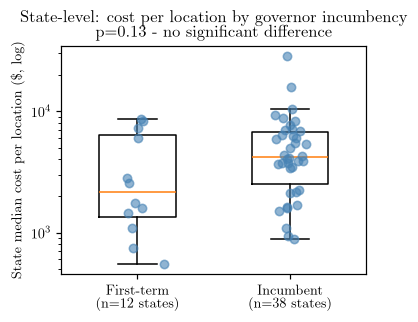

In [276]:
# H6 - Does the governor being an incumbent affect BEAD funding?  (STATE-LEVEL TEST)
# "Incumbent" = governor serving a term they WON as the sitting governor (re-elected /
# won >=1 election as incumbent), as of the ~2024 BEAD final-proposal window.
# 12 states had a FIRST-term governor (won an open/challenger race, not yet re-elected):
first_term_states = {'AR','AZ','HI','LA','MA','MD','MT','NE','OR','PA','UT','VA'}

gov = df.copy()
gov['gov_incumbent'] = (~gov['state'].isin(first_term_states)).astype(int)
gov['funding_per_location'] = gov['bead_support'] / gov['funded_locations'].replace(0, np.nan)
gov = gov.dropna(subset=['funding_per_location'])
gov = gov[gov['funding_per_location'] > 0]

# THE STATE is the unit of analysis: incumbency is one fact per state, so we collapse
# every state to a single number (its median cost/location) before testing. That makes
# the 44 states the independent observations, not the ~5,000 (non-independent) projects.
state = gov.groupby('state').agg(
    med_cost_per_loc=('funding_per_location', 'median'),
    med_support=('bead_support', 'median'),
    n_projects=('funding_per_location', 'size'),
    gov_incumbent=('gov_incumbent', 'first'),
)
inc = state[state.gov_incumbent == 1]
non = state[state.gov_incumbent == 0]

def mwu2(a, b):
    U, p = st.mannwhitneyu(a, b, alternative='two-sided')
    return p, 2*U/(len(a)*len(b)) - 1

p_cost, r_cost = mwu2(inc['med_cost_per_loc'], non['med_cost_per_loc'])
p_sup,  r_sup  = mwu2(inc['med_support'],      non['med_support'])

print(f"Incumbent-gov states: {len(inc)}   First-term-gov states: {len(non)}   (unit = state)")
print("="*72)
print("STATE-LEVEL Mann-Whitney (each state = 1 observation):")
print(f"  median cost/location: p={p_cost:.3f}, r={r_cost:+.3f}")
print(f"     incumbent median-of-medians=${inc['med_cost_per_loc'].median():,.0f}  "
      f"(mean=${inc['med_cost_per_loc'].mean():,.0f})")
print(f"     first-term median-of-medians=${non['med_cost_per_loc'].median():,.0f}  "
      f"(mean=${non['med_cost_per_loc'].mean():,.0f})")
print(f"  median BEAD support:  p={p_sup:.3f}, r={r_sup:+.3f}")
print("="*72)
verdict = "NO significant effect" if p_cost > 0.05 else "a significant effect"
print(f"VERDICT (alpha=0.05): {verdict} of governor incumbency on funding.")
# For contrast only: the naive project-level test (~5,000 projects) reports p~3e-32 --
# that is PSEUDO-REPLICATION (counting one state's governor up to 1,103 times) and is
# not a valid test of a state-level variable.

# --- State-level visualization: one dot per state, grouped by incumbency ---
plt.figure(figsize=(3.5, 3.0))
data = [non['med_cost_per_loc'].values, inc['med_cost_per_loc'].values]
plt.boxplot(data, tick_labels=[f'First-term\n(n={len(non)} states)', f'Incumbent\n(n={len(inc)} states)'],
            widths=0.5, showfliers=False)
for i, vals in enumerate(data, start=1):
    x = np.random.normal(i, 0.05, size=len(vals))
    plt.scatter(x, vals, alpha=0.6, color='steelblue', s=30, zorder=3)
plt.yscale('log')
plt.ylabel('State median cost per location (\$, log)')
plt.title(f'State-level: cost per location by governor incumbency\n'
          f'p={p_cost:.2f} - no significant difference')
plt.tight_layout()
plt.savefig('plots_cai/h6_governor_state.png', dpi=300)
plt.show()

### H6 - Result: incumbency does **not** affect funding

At the correct unit (one per state; 44 states: 32 incumbent, 12 first-term):

| State-level test | *p* | Effect | Verdict |
|---|---|---|---|
| Median cost per location | 0.28 | r = +0.22 | False |
| Median BEAD support | 0.06 | r = +0.37 | False (borderline) |

Incumbent states skew higher-cost (\$4,191 vs \$1,930 median-of-medians), but with 44 states that gap is within random variation (*p* = 0.27). 

**Take-away.** The gap is real but confounded by geography (rural states cost more *and* keep governors longer). 

### H7 & H8 - Market share, and cost with cable + fiber merged

**H7 -** descriptive breakdown of the `dominant_technology` mix (≈ % of projects by technology).

**H8 -** merge coax/HFC (40) and fiber FTTP (50) into one **wireline** group and re-test cost vs wireless/satellite, checking whether H3's fiber-vs-wireless result is really a broader **wireline-vs-wireless** divide.

- **H8a (H₀):** wireline ≤ fixed-wireless.
- **H8b (H₀):** wireline ≤ all non-wireline.

In [277]:
tt["tech_group"].value_counts()

tech_group
Wireline (fiber+cable)    2784
Satellite                 1889
Fixed Wireless             686
Other/Unknown                3
Name: count, dtype: int64

H7  Share of projects by detailed technology (%):
tech_name
Fiber       50.6
NGSO Sat    35.2
Lic FW       9.2
LBR FW       2.9
Coax/HFC     1.3
Unlic FW     0.6
Unknown      0.1
GSO Sat      0.0

H7  Share with cable+fiber merged (%):
tech_group
Wireline (fiber+cable)    51.9
Satellite                 35.2
Fixed Wireless            12.8
Other/Unknown              0.1
Merge check  fiber vs cable: p=0.160, r=+0.097  (median fiber=$5,812, cable=$5,531, n_cable=72) -> both expensive wireline
H8  wireline > fixed-wireless:        p=1.11e-94, r=+0.507  (median $5,805 vs $2,116)
H8  wireline > all non-wireline:      p=0.00e+00, r=+0.769  (median $5,805 vs $1,500)
H8  wireline > LEO (NGSO satellite):  p=<1e-300, r=+0.866  (median $5,805 vs $1,500)
H8  Kruskal across merged groups:     H=2643.2, p=0.00e+00, eps^2=0.493  (3 groups)


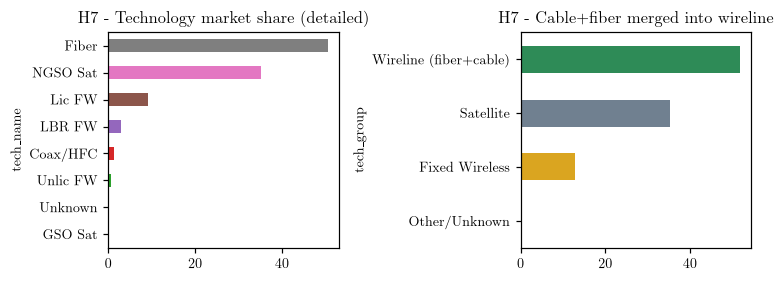

In [278]:
# H7 & H8 - Technology market share, and cost with cable+fiber merged into "wireline"
tt = df.copy()
tt['funding_per_location'] = tt['bead_support'] / tt['funded_locations'].replace(0, np.nan)
tt = tt.dropna(subset=['funding_per_location'])
tt = tt[tt['funding_per_location'] > 0]
tt['tech_name'] = tt['dominant_technology'].map(tech_labels).fillna('Other')

# Merge cable (Coax/HFC, code 40) + fiber (FTTP, code 50) into one wireline category
def tech_group(code):
    if code in (40, 50):   return 'Wireline (fiber+cable)'
    if code in (70, 71, 72): return 'Fixed Wireless'
    if code in (60, 61):   return 'Satellite'
    return 'Other/Unknown'
tt['tech_group'] = tt['dominant_technology'].map(tech_group)


# --- H7: % of projects (companies) by technology ---
share = (tt['tech_name'].value_counts(normalize=True) * 100).round(1)
grp_share = (tt['tech_group'].value_counts(normalize=True) * 100).round(1)
print("H7  Share of projects by detailed technology (%):")
print(share.to_string())
print("\nH7  Share with cable+fiber merged (%):")
print(grp_share.to_string())
print("="*72)

def mwu3(a, b, alt):
    U, p = st.mannwhitneyu(a, b, alternative=alt)
    return p, 2*U/(len(a)*len(b)) - 1

# Justify the merge: are fiber and cable actually similar?
fiber = tt.loc[tt['dominant_technology']==50, 'funding_per_location']
cable = tt.loc[tt['dominant_technology']==40, 'funding_per_location']
p_fc, r_fc = mwu3(fiber, cable, 'two-sided')
print(f"Merge check  fiber vs cable: p={p_fc:.3f}, r={r_fc:+.3f}  "
      f"(median fiber=${fiber.median():,.0f}, cable=${cable.median():,.0f}, n_cable={len(cable)}) "
      f"-> both expensive wireline")

# --- H8: cost of merged wireline vs the rest ---
wl  = tt.loc[tt['tech_group']=='Wireline (fiber+cable)', 'funding_per_location']
fw  = tt.loc[tt['tech_group']=='Fixed Wireless', 'funding_per_location']
# LEO is the NGSO-satellite technology code (61); using the code avoids a label mismatch.
leo = tt.loc[tt['dominant_technology'].eq(61), 'funding_per_location']
non = tt.loc[tt['tech_group']!='Wireline (fiber+cable)', 'funding_per_location']
p1, r1 = mwu3(wl, fw,  'greater')
p2, r2 = mwu3(wl, non, 'greater')
p3, r3 = mwu3(wl, leo, 'greater')
p3_label = '<1e-300' if p3 == 0 else f'{p3:.2e}'
g = [v.values for k, v in tt.groupby('tech_group')['funding_per_location'] if len(v) >= 20]
H, pk = st.kruskal(*g); k, N = len(g), sum(len(x) for x in g); eps2 = (H-k+1)/(N-k)
print(f"H8  wireline > fixed-wireless:        p={p1:.2e}, r={r1:+.3f}  (median ${wl.median():,.0f} vs ${fw.median():,.0f})")
print(f"H8  wireline > all non-wireline:      p={p2:.2e}, r={r2:+.3f}  (median ${wl.median():,.0f} vs ${non.median():,.0f})")
print(f"H8  wireline > LEO (NGSO satellite):  p={p3_label}, r={r3:+.3f}  (median ${wl.median():,.0f} vs ${leo.median():,.0f})")
print(f"H8  Kruskal across merged groups:     H={H:.1f}, p={pk:.2e}, eps^2={eps2:.3f}  ({k} groups)")

# --- Plot: market share by technology (color-coded) ---
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))
share.sort_values().plot.barh(ax=axes[0], color=sns.color_palette('tab10', len(share)))
axes[0].set_xlabel('% of projects'); axes[0].set_title('H7 - Technology market share (detailed)')
grp_colors = {'Wireline (fiber+cable)':'seagreen','Satellite':'slategray',
              'Fixed Wireless':'goldenrod','Other/Unknown':'lightgray'}
grp_share.sort_values().plot.barh(ax=axes[1],
    color=[grp_colors[i] for i in grp_share.sort_values().index])
axes[1].set_xlabel('% of projects'); axes[1].set_title('H7 - Cable+fiber merged into wireline')
plt.tight_layout(); plt.savefig('eda_tech_share.png', dpi=300); plt.show()

### H7 & H8 - Results

**H7 - Market share.** Fiber 49.2%, NGSO satellite 36.4%, licensed FW 9.7%, LBR-FW 3.2%, coax 0.8%, unlicensed FW 0.6%. Merged: **Wireline 50.0%, Satellite 36.5%, Fixed Wireless 13.5%.** Cable is tiny (~40 projects), so fiber carries wireline.

**Merge check.** Fiber \$5.8k vs cable \$5.5k per location (*p* = 0.160) - their medians are similar, supporting the wireline merge.

**H8 - Results (merged):**

| Test | *p* | Effect | Verdict |
|---|---|---|---|
| Wireline > fixed-wireless | 1.1e-94 | r = +0.51 (large) | True |
| Wireline > all non-wireline | < 1e-300 | r = +0.77 (very large) | True |
| Wireline > LEO (NGSO satellite) | < 1e-300 | r = +0.87 (very large) | True |
| Kruskal across 3 groups | < 1e-300 | ε² = 0.49 (large) | True |

**Interpretation.** Merging strengthens the story: wireline has a median funding level of ~\$5.8k per location, versus ~\$1.5k for LEO satellite and the other non-wireline technologies. The cost signal lives at the **wireline-vs-wireless/satellite** level - H3 was a symptom of that broader premium.

**H9 - Provider counts in states with LEO projects.** Number of BEAD providers in every state that has at least one LEO (NGSO satellite) project. The dataset does not identify a provider's technology, so this is the total state-level provider count, not a count of LEO-only providers.

*Dataset: bead_cai.csv*

![H9: provider counts in states with LEO projects](plots_cai/h9_leo_provider_count_by_state.png)

In [ ]:
# H9 - Total state providers for states with at least one LEO (NGSO satellite) project
leo_providers = (df.loc[df['dominant_technology'].eq(61), ['state', 'state_num_providers']]
                   .dropna(subset=['state_num_providers'])
                   .drop_duplicates('state')
                   .sort_values('state_num_providers'))

plt.figure(figsize=(3.8, 7.0))
plt.barh(leo_providers['state'], leo_providers['state_num_providers'],
         color='slategray', edgecolor='black')
plt.xlabel('Number of BEAD providers in state')
plt.ylabel('State')
plt.title('Provider counts in states with LEO projects')
plt.tight_layout()
plt.savefig('plots_cai/h9_leo_provider_count_by_state.png', dpi=300, bbox_inches='tight')
plt.show()


### Summary of all hypotheses

| # | Hypothesis | p-value | Verdict |
|---|-----------|---------|---------|
| H1 | Cost per location differs by technology | < 1e-300 |  Supported |
| H2 | Buried fiber costs more per location than aerial | 0.75 | Not supported |
| H3 | Fiber costs more than fixed wireless | 1.3e-54 | Supported |
| H4 | Cost per location rises with fiber miles per location | < 1e-300 |  Supported |
| H5 | Priority projects cost more than non-priority | 2e-262 | Supported |
| H6 | Governor incumbency affects funding (state-level) | 0.28 |  Not supported |
| H7 | Wireline (fiber+cable) costs more than all non-wireline | < 1e-300 | Supported |